In [6]:
%matplotlib inline
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import seaborn as sns


import pyBigWig



plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6


In [7]:
cat_colors_list = ['#263238', '#2E5BFF', "#D4AF37",  '#D81B60','#E65100',  '#7B1FA2',  '#558B2F',]  # ,   '#94A3B8'
unique_categories =['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+TSS, not CR', 'SADE+CR, not TSS']
cat_colors_map = dict(zip(unique_categories, cat_colors_list))   

In [8]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 1 + [jitter_width] * 3  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))

In [9]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size

In [10]:
hg38_genes_file='/home/syyang/GitRepo/SADE/EDA/Info_from_CellRanger/genes/genes.gtf.gz' #'/home/syyang/CR/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz'
hg38_genes_df = pd.read_csv(hg38_genes_file, sep='\t', comment='#', header=None,
                            names=['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'],
                            compression='gzip')
hg38_genes_genes_df = hg38_genes_df[hg38_genes_df['feature'] == 'gene'].copy()


hg38_genes_genes_df['gene_name'] = hg38_genes_genes_df['attribute'].apply(lambda x: [item for item in x.split(';') if 'gene_name' in item][0].split(' ')[-1].replace('"', ''))
hg38_genes_genes_df.head(2)

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_name
0,chr1,HAVANA,gene,29554,31109,.,+,.,"gene_id ""ENSG00000243485""; gene_version ""5""; g...",MIR1302-2HG
8,chr1,HAVANA,gene,34554,36081,.,-,.,"gene_id ""ENSG00000237613""; gene_version ""2""; g...",FAM138A


In [11]:
# blacklist region 
blacklist_region_file = '/home/syyang/GitRepo/SADE/ref/hg38/hg38-blacklist.bed'
blacklist_region_df = pd.read_csv(blacklist_region_file, sep='\t', header=None, names=['chrom', 'start', 'end', 'name'])
blacklist_region_df.head(2)

,chrom,start,end,name
0,chr10,0,45700,Low Mappability
1,chr10,38481300,38596500,High Signal Region


# Load Data

## Load entropy results

In [12]:
# Load Entropy value for each barcode on atac (if any barcode has invalid entropy value, it's not included in the file)
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy
AAGCCATAGCTAATAG-1,0.005725,1.069145,11,0.343957,0.708959,0.999545,NO,-2.242193
CACGGTAAGAATCACA-1,0.004039,1.910865,19,1.377521,0.252203,0.999694,NO,-2.393755


In [13]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['invalid_entropy'] = union_cell_info['Entropy'].isna()
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state,invalid_entropy
atac_barcodes,,,,,,,,,,,
AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,common,0.218328,NO,0.965116,False
AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,common,0.074451,NO,0.990949,False


In [14]:
union_cell_info['Entropy'].isna().sum()

np.int64(22)

## Given some barcodes could have invalid entropy and does not have a record -- load fragment file 

In [15]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index
frag['frag_length'] = frag['end'] - frag['start']

total_frag_per_bc = frag.groupby('atac_bc').size()

# Visualize fragment length distribution

In [16]:
bc_DNAdebris_list = union_cell_info.loc[union_cell_info['DNA_debris'] == 'YES'].index.tolist()
bc_invalid_entropy_list = union_cell_info.loc[union_cell_info['invalid_entropy']].index.tolist()

bc_entropy_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE unique'].index.tolist()
bc_cr_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'CR unique'].index.tolist()
bc_tss_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'TSS unique'].index.tolist()
bc_common_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'common'].index.tolist()
bc_SADEnCR_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE+CR, not TSS'].index.tolist()
bc_SADEnTSS_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE+TSS, not CR'].index.tolist()
bc_CRnTSS_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'CR+TSS, not SADE'].index.tolist()

In [17]:
union_cell_info['_3set_identified_by_atac'].value_counts()

_3set_identified_by_atac
common              1792
TSS unique           189
SADE+TSS, not CR     118
SADE unique          118
SADE+CR, not TSS      73
CR unique             61
CR+TSS, not SADE      33
Name: count, dtype: int64

In [18]:
union_cell_info['_2set_identified_by_atac_SC_mod'] = union_cell_info['_2set_identified_by_atac_SC'].replace('none', 'tss_unique')

In [19]:
union_cell_info['_2set_identified_by_atac_SC_mod'] .value_counts()

_2set_identified_by_atac_SC_mod
both            1865
entropy_only     236
tss_unique       189
cr_only           94
Name: count, dtype: int64

## Invalid Entropy barcodes

In [20]:
union_cell_info.loc[bc_invalid_entropy_list].head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state,invalid_entropy,_2set_identified_by_atac_SC_mod
atac_barcodes,,,,,,,,,,,,
AAGCTAGGTTACTTCT-1,3245,False,False,True,none,tss_only,TSS unique,NaN,NaN,NaN,True,tss_unique
ACATTACTCATTACAC-1,517,True,False,False,cr_only,none,CR unique,NaN,NaN,NaN,True,cr_only


Text(0.06, 0.5, 'Frequency')

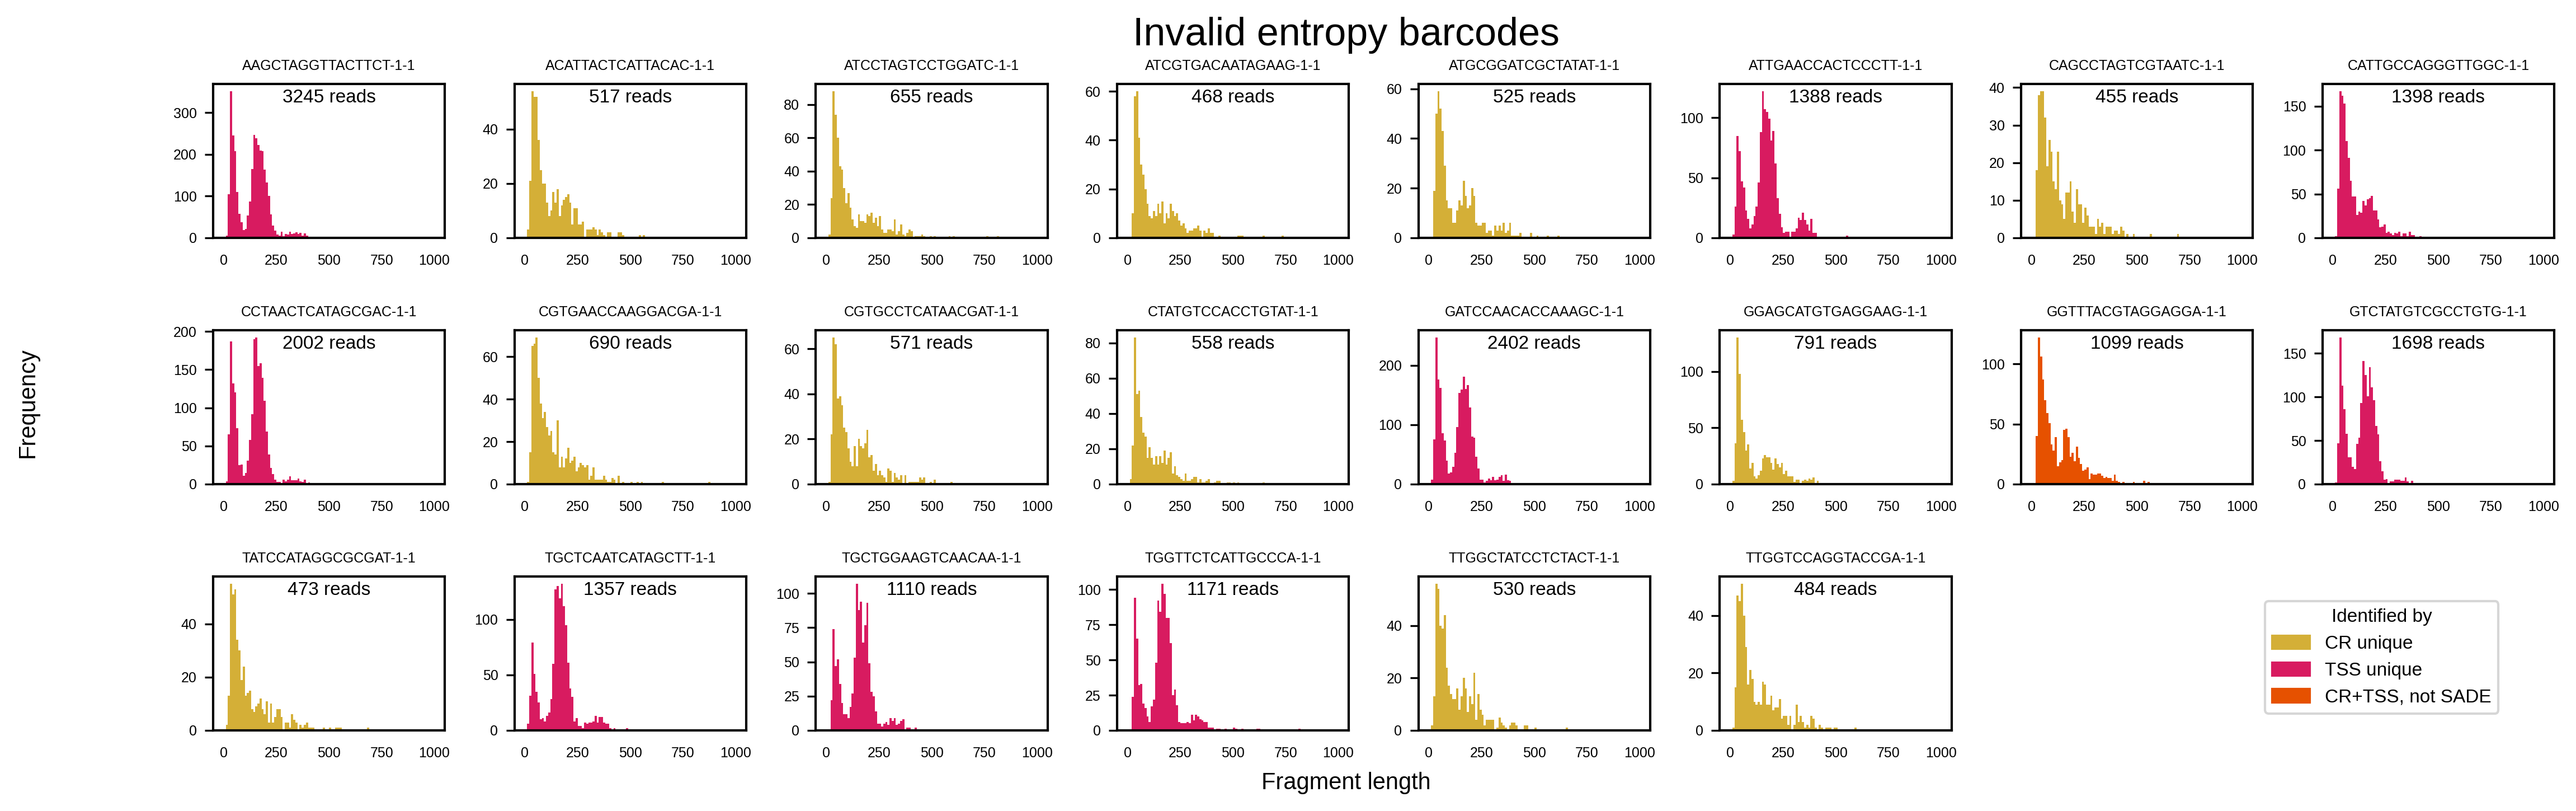

In [21]:
ncol = 8
nrow = len(bc_invalid_entropy_list)//ncol + 1
fig, ax = plt.subplots(nrow, ncol, figsize=(18, 5))
fig.subplots_adjust(hspace=0.6, wspace=0.3)   # increase row/column gaps
ax = ax.flatten()

shown_methods = []
for i, bc in enumerate(bc_invalid_entropy_list):
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    frag_c = frag.loc[frag['atac_bc'] == bc, 'frag_length']
    _ = ax[i].hist(frag_c, bins=100, range=(0, 1000), color=cat_colors_map.get(identified_method, 'grey'))
    ax[i].text(0.5, 0.88, f'{len(frag_c)} reads', transform=ax[i].transAxes, ha='center', fontsize=8, color='black')
    ax[i].set_title(bc + '-1', fontsize=6)
    ax[i].tick_params(axis='both', which='major', bottom=False,  labelsize=6)
        
    shown_methods.append(identified_method)

for i in range(len(bc_invalid_entropy_list), len(ax)):
    ax[i].axis('off')
handles=[mpatches.Patch(color=cat_colors_map[method], label=method) for method in unique_categories if method in set(shown_methods)]
ax[-1].legend(handles=handles, loc='upper right', bbox_to_anchor=(0.8, 0.9), title='Identified by', 
             fontsize=8, title_fontsize=8)


fig.suptitle('Invalid entropy barcodes', y=0.96)
fig.text(0.5, 0.04, 'Fragment length', ha='center', fontsize=10)
fig.text(0.06, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=10)


### A closer look at genome track of those barcodes

In [22]:
per_bc_subdir = os.path.join(Union_cell_subdir,'per_bc_frag_bam2')

[urlOpen] Couldn't open /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/per_bc_frag_bam2/GCTACCTAGGCGCAGT-1-1_fragments.bw for reading
[urlOpen] Couldn't open /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/per_bc_frag_bam2/GCTACCTAGGCGCAGT-1-1_fragments.bw for reading
[pyBwOpen] bw is NULL!


RuntimeError: Received an error during file opening!

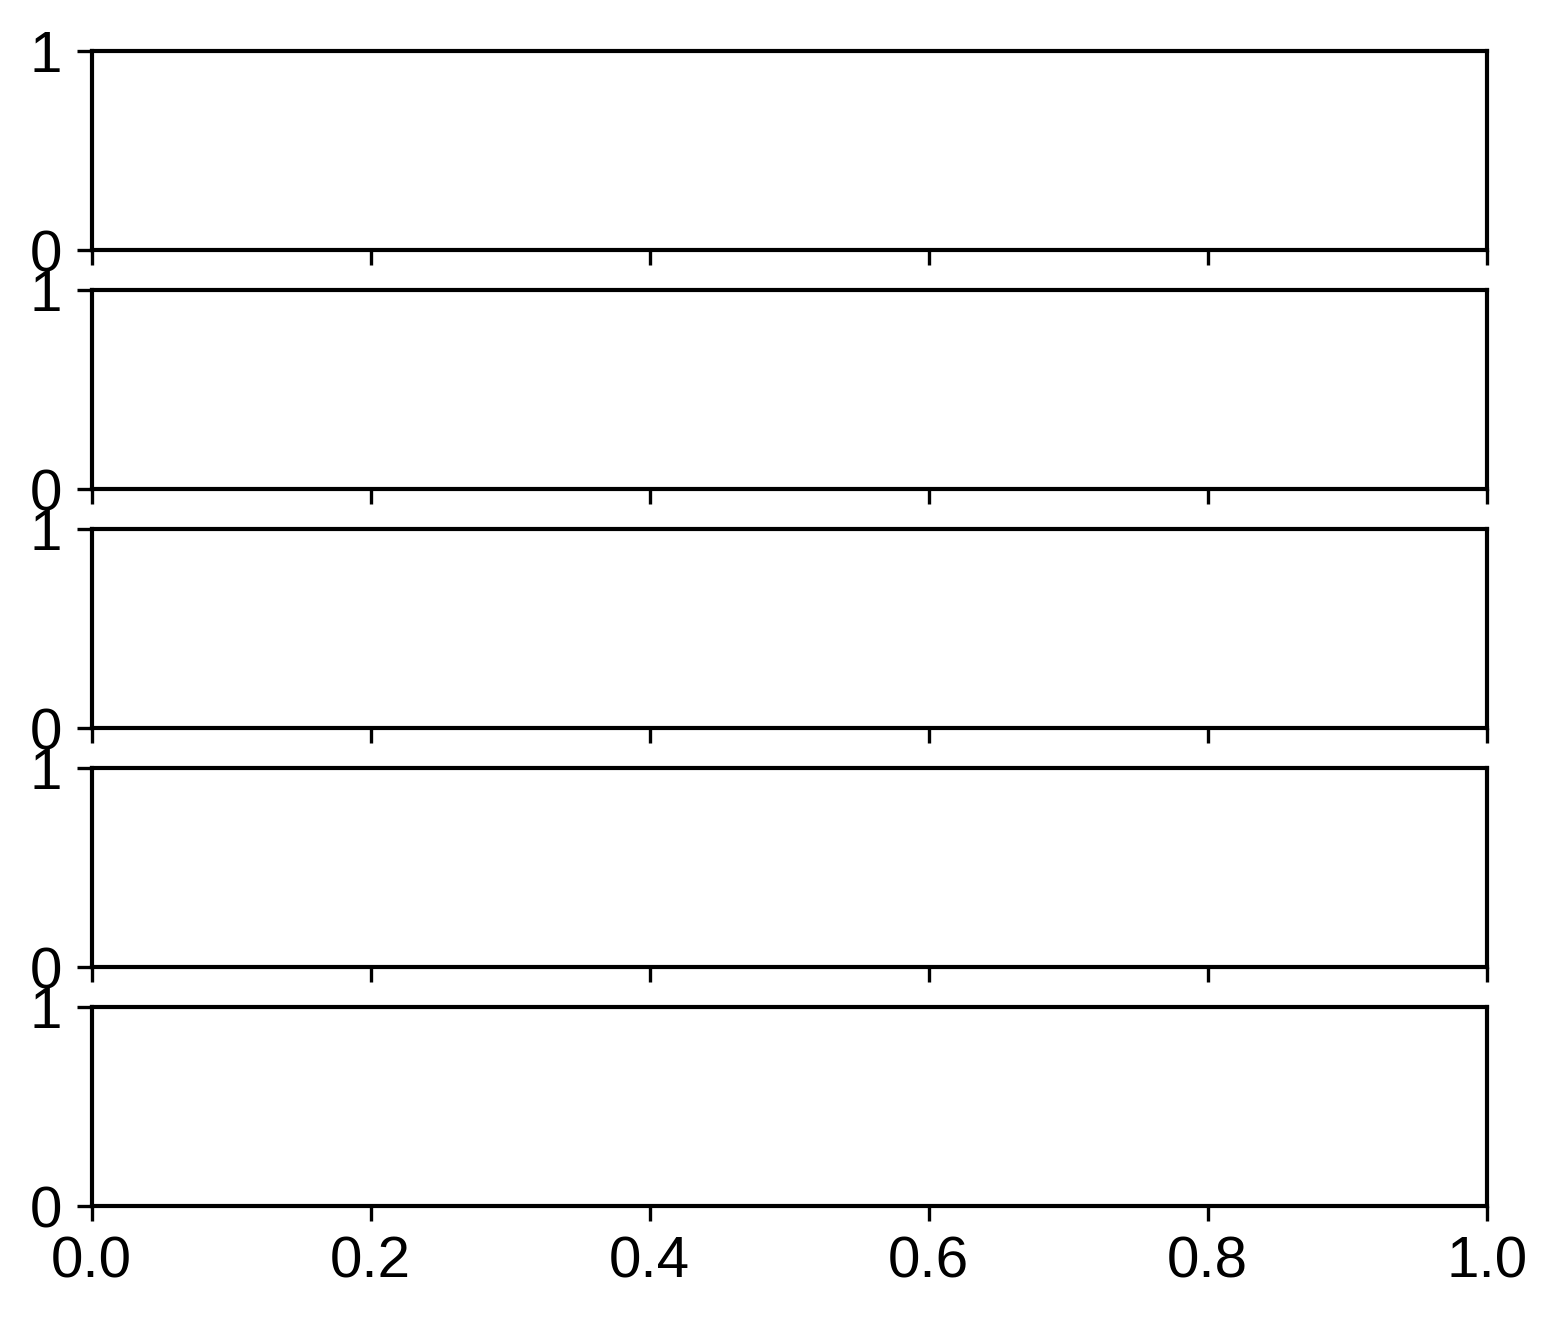

In [ ]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=5, figsize=(6, 5), sharex=True)
ax = ax.flatten()

shown_methods = []
np.random.seed(999)  # For reproducibility
for i, bc in enumerate(list(np.random.choice(bc_common_list, size=2, replace=False)) + bc_invalid_entropy_list):
    if i >= len(ax)  :
        break
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
        
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[i].plot(np.linspace(0, bc_chrom_size, bins), bc_binned_stats, label=bc, color=cat_colors_map.get(identified_method, 'green'), linewidth=1)
    #ax[i].text(0.7, 0.8, f'{read_depth} reads', transform=ax[i].transAxes, ha='center', fontsize=8, color='black')
    ax[i].set_title(f'{bc}-1 , {read_depth} reads ({identified_method} barcodes)', fontsize=8,   pad=1, x=0.4, y=0.75, fontweight='bold')
    y_lim = max(ax[i].get_ylim()[1], 2.1)
    ax[i].set_ylim(0, y_lim)
    ax[i].set_yticks(np.arange(y_lim))
    ax[i].tick_params(axis='both', which='major', bottom=False,  labelsize=8)
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='grey', alpha=1)
    bc_bw.close()



fig.suptitle(f'{chrom} ', y=0.94)
fig.supylabel('Max read depth',fontsize=10,  x=0.07, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.04, )


Identified methods for invalid entropy barcodes: ['TSS unique' 'CR unique' 'CR+TSS, not SADE']


Text(0.5, 0.05, 'Chromosome Position')

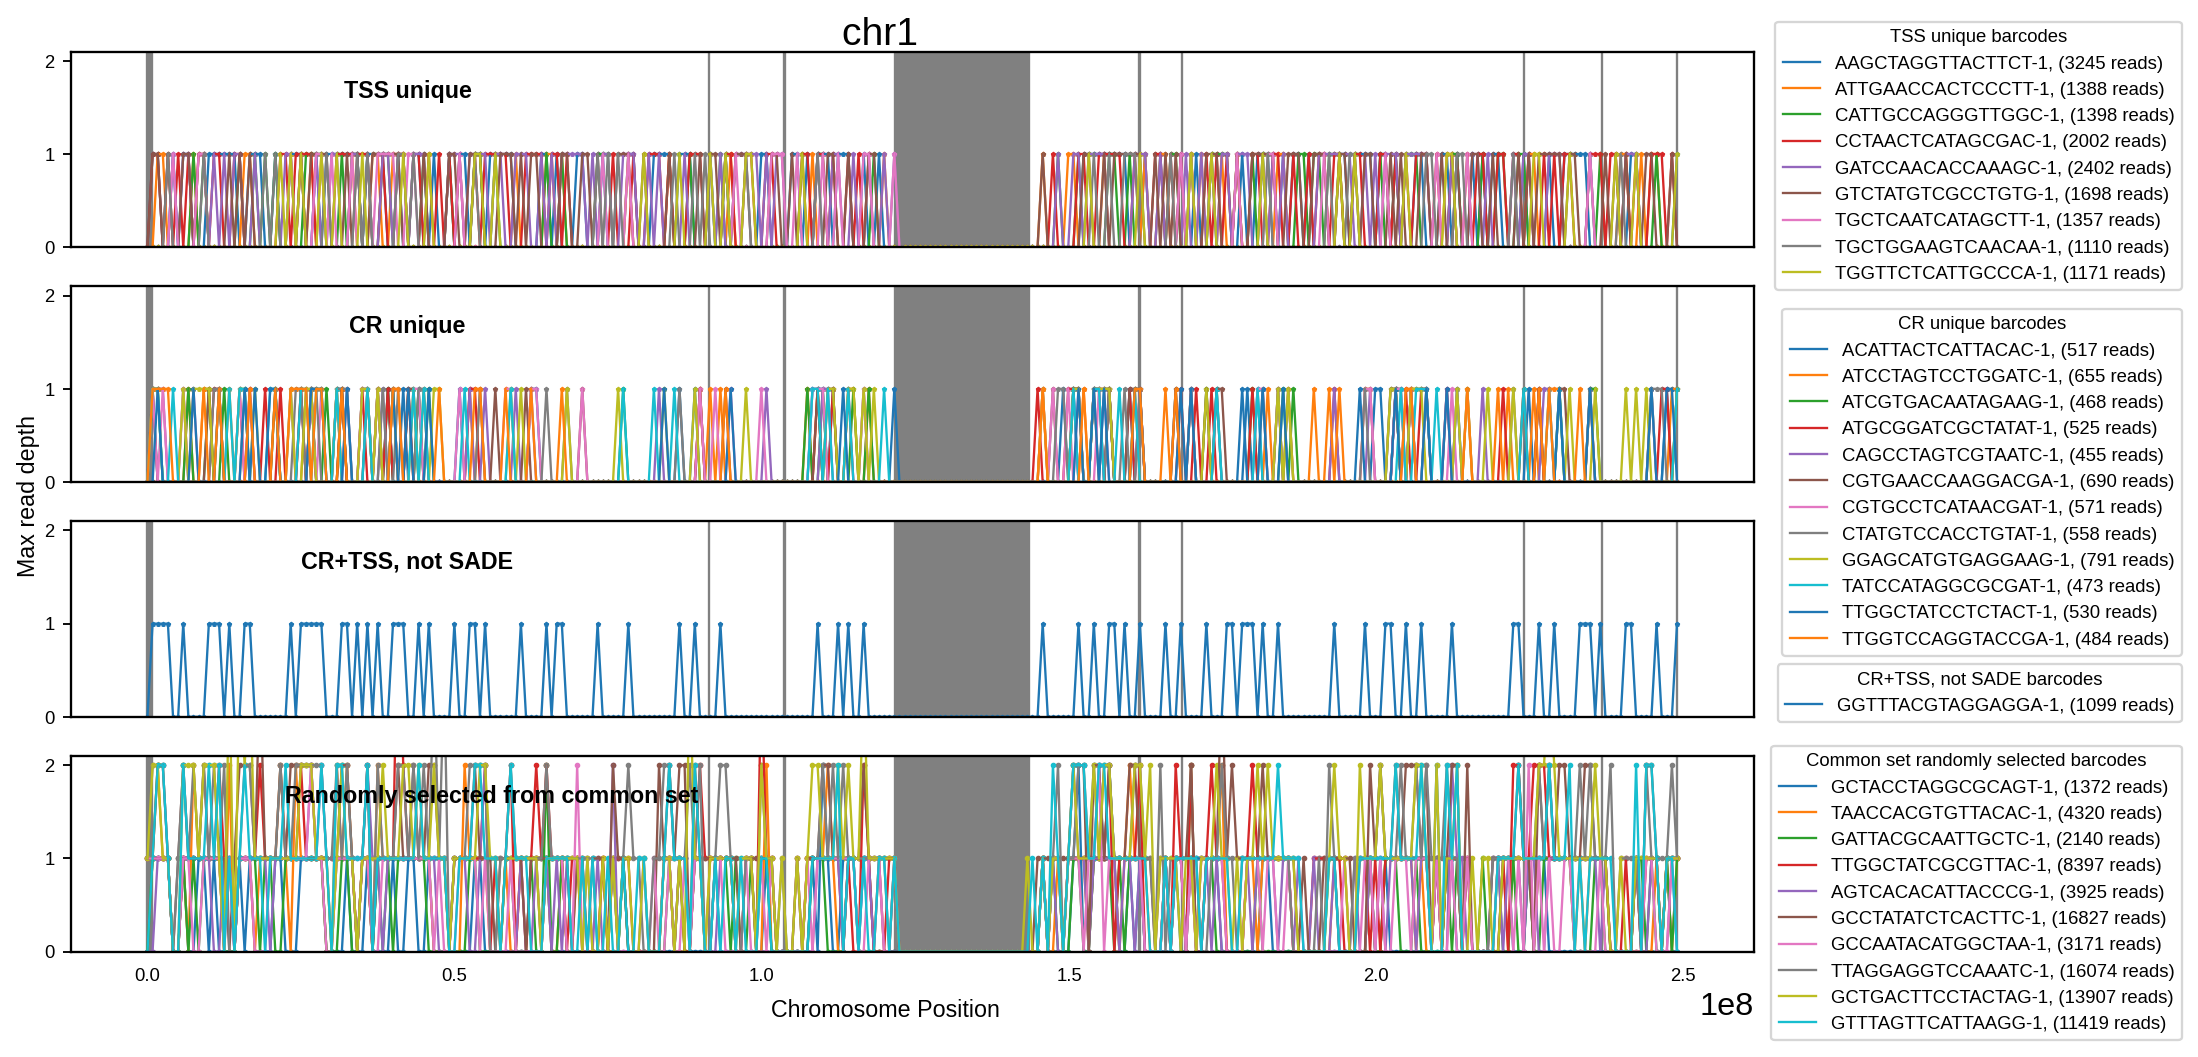

In [19]:
chrom = "chr1"
bins = 300

fig,ax = plt.subplots(ncols=1, nrows=4, figsize=(13, 7), sharex=True)
ax = ax.flatten()

shown_methods = []

for nr in range(len(ax)):
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[nr].axvspan(row['start'], row['end'], color='grey', alpha=1)
    bc_bw.close()

identified_method_set =  union_cell_info.loc[bc_invalid_entropy_list, '_3set_identified_by_atac'].unique()
print(f'Identified methods for invalid entropy barcodes: {identified_method_set}')
identified_mathod_ax_map = dict(zip(identified_method_set, range(len(identified_method_set))))
for i, bc in enumerate(bc_invalid_entropy_list):

    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
        
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[identified_mathod_ax_map[identified_method]].set_title(identified_method, fontsize=10,   pad=1, x=0.2, y=0.75, fontweight='bold')
    ax[identified_mathod_ax_map[identified_method]].plot(np.linspace(0, bc_chrom_size, bins),  np.array(bc_binned_stats), linewidth=1,  #color=cat_colors_map.get(identified_method, 'grey'),
               label=f'{bc}-1, ({read_depth} reads)')
    ax[identified_mathod_ax_map[identified_method]].scatter(np.linspace(0, bc_chrom_size, bins), np.array(bc_binned_stats),s=2, marker='*')

    y_lim = max(ax[identified_mathod_ax_map[identified_method]].get_ylim()[1], 2.1) # to show value at 2.
    ax[identified_mathod_ax_map[identified_method]].set_ylim(0, y_lim)
    ax[identified_mathod_ax_map[identified_method]].set_yticks(np.arange(y_lim))
    ax[identified_mathod_ax_map[identified_method]].tick_params(axis='both', which='major', bottom=False,  labelsize=8)

np.random.seed(999)  # For reproducibility
for i, bc in enumerate(np.random.choice(bc_common_list, size=10, replace=False)):

    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
        
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[-1].plot(np.linspace(0, bc_chrom_size, bins), np.array(bc_binned_stats) ,  linewidth=1,
               label=f'{bc}-1, ({read_depth} reads)')
    ax[-1].scatter(np.linspace(0, bc_chrom_size, bins), np.array(bc_binned_stats) , s=2)

    y_lim = max(ax[-1].get_ylim()[1], 2.1) # to show value at 2.
    ax[-1].set_title('Randomly selected from common set', fontsize=10,   pad=1, x=0.25, y=0.75, fontweight='bold')
    ax[-1].set_ylim(0, y_lim)
    ax[-1].set_yticks(np.arange(y_lim))
    ax[-1].tick_params(axis='both', which='major', bottom=False,  labelsize=8)

for nr in range(len(ax)):
    ax[nr].legend(loc='upper right', bbox_to_anchor=(1.26, 1.2 - 0.8 * (nr/3) - (nr==2) * 0.35 + 0.7 *(nr==3) ), title=f'{identified_method_set[nr] if nr < 3 else "Common set randomly selected"} barcodes', fontsize=8, title_fontsize=8)
fig.suptitle(f'{chrom} ', y=0.91)
fig.supylabel('Max read depth',fontsize=10,  x=0.1, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.05, )


## Cellular-debris 

In [21]:
union_cell_info.loc[union_cell_info['DNA_debris'] =='YES', 'total_fragments'].sum() /  union_cell_info.loc[union_cell_info['atac_pass_CR'], 'total_fragments'].sum()

np.float64(0.5114908262814838)

In [22]:
union_cell_info.loc[union_cell_info['DNA_debris'] =='YES', 'total_fragments'].mean() 

np.float64(1006448.4090909091)

In [23]:
union_cell_info.loc[union_cell_info['DNA_debris'] =='YES', 'total_fragments'].sum()

np.int64(22141865)

Text(0.5, 0.93, 'Cellular debris barcodes')

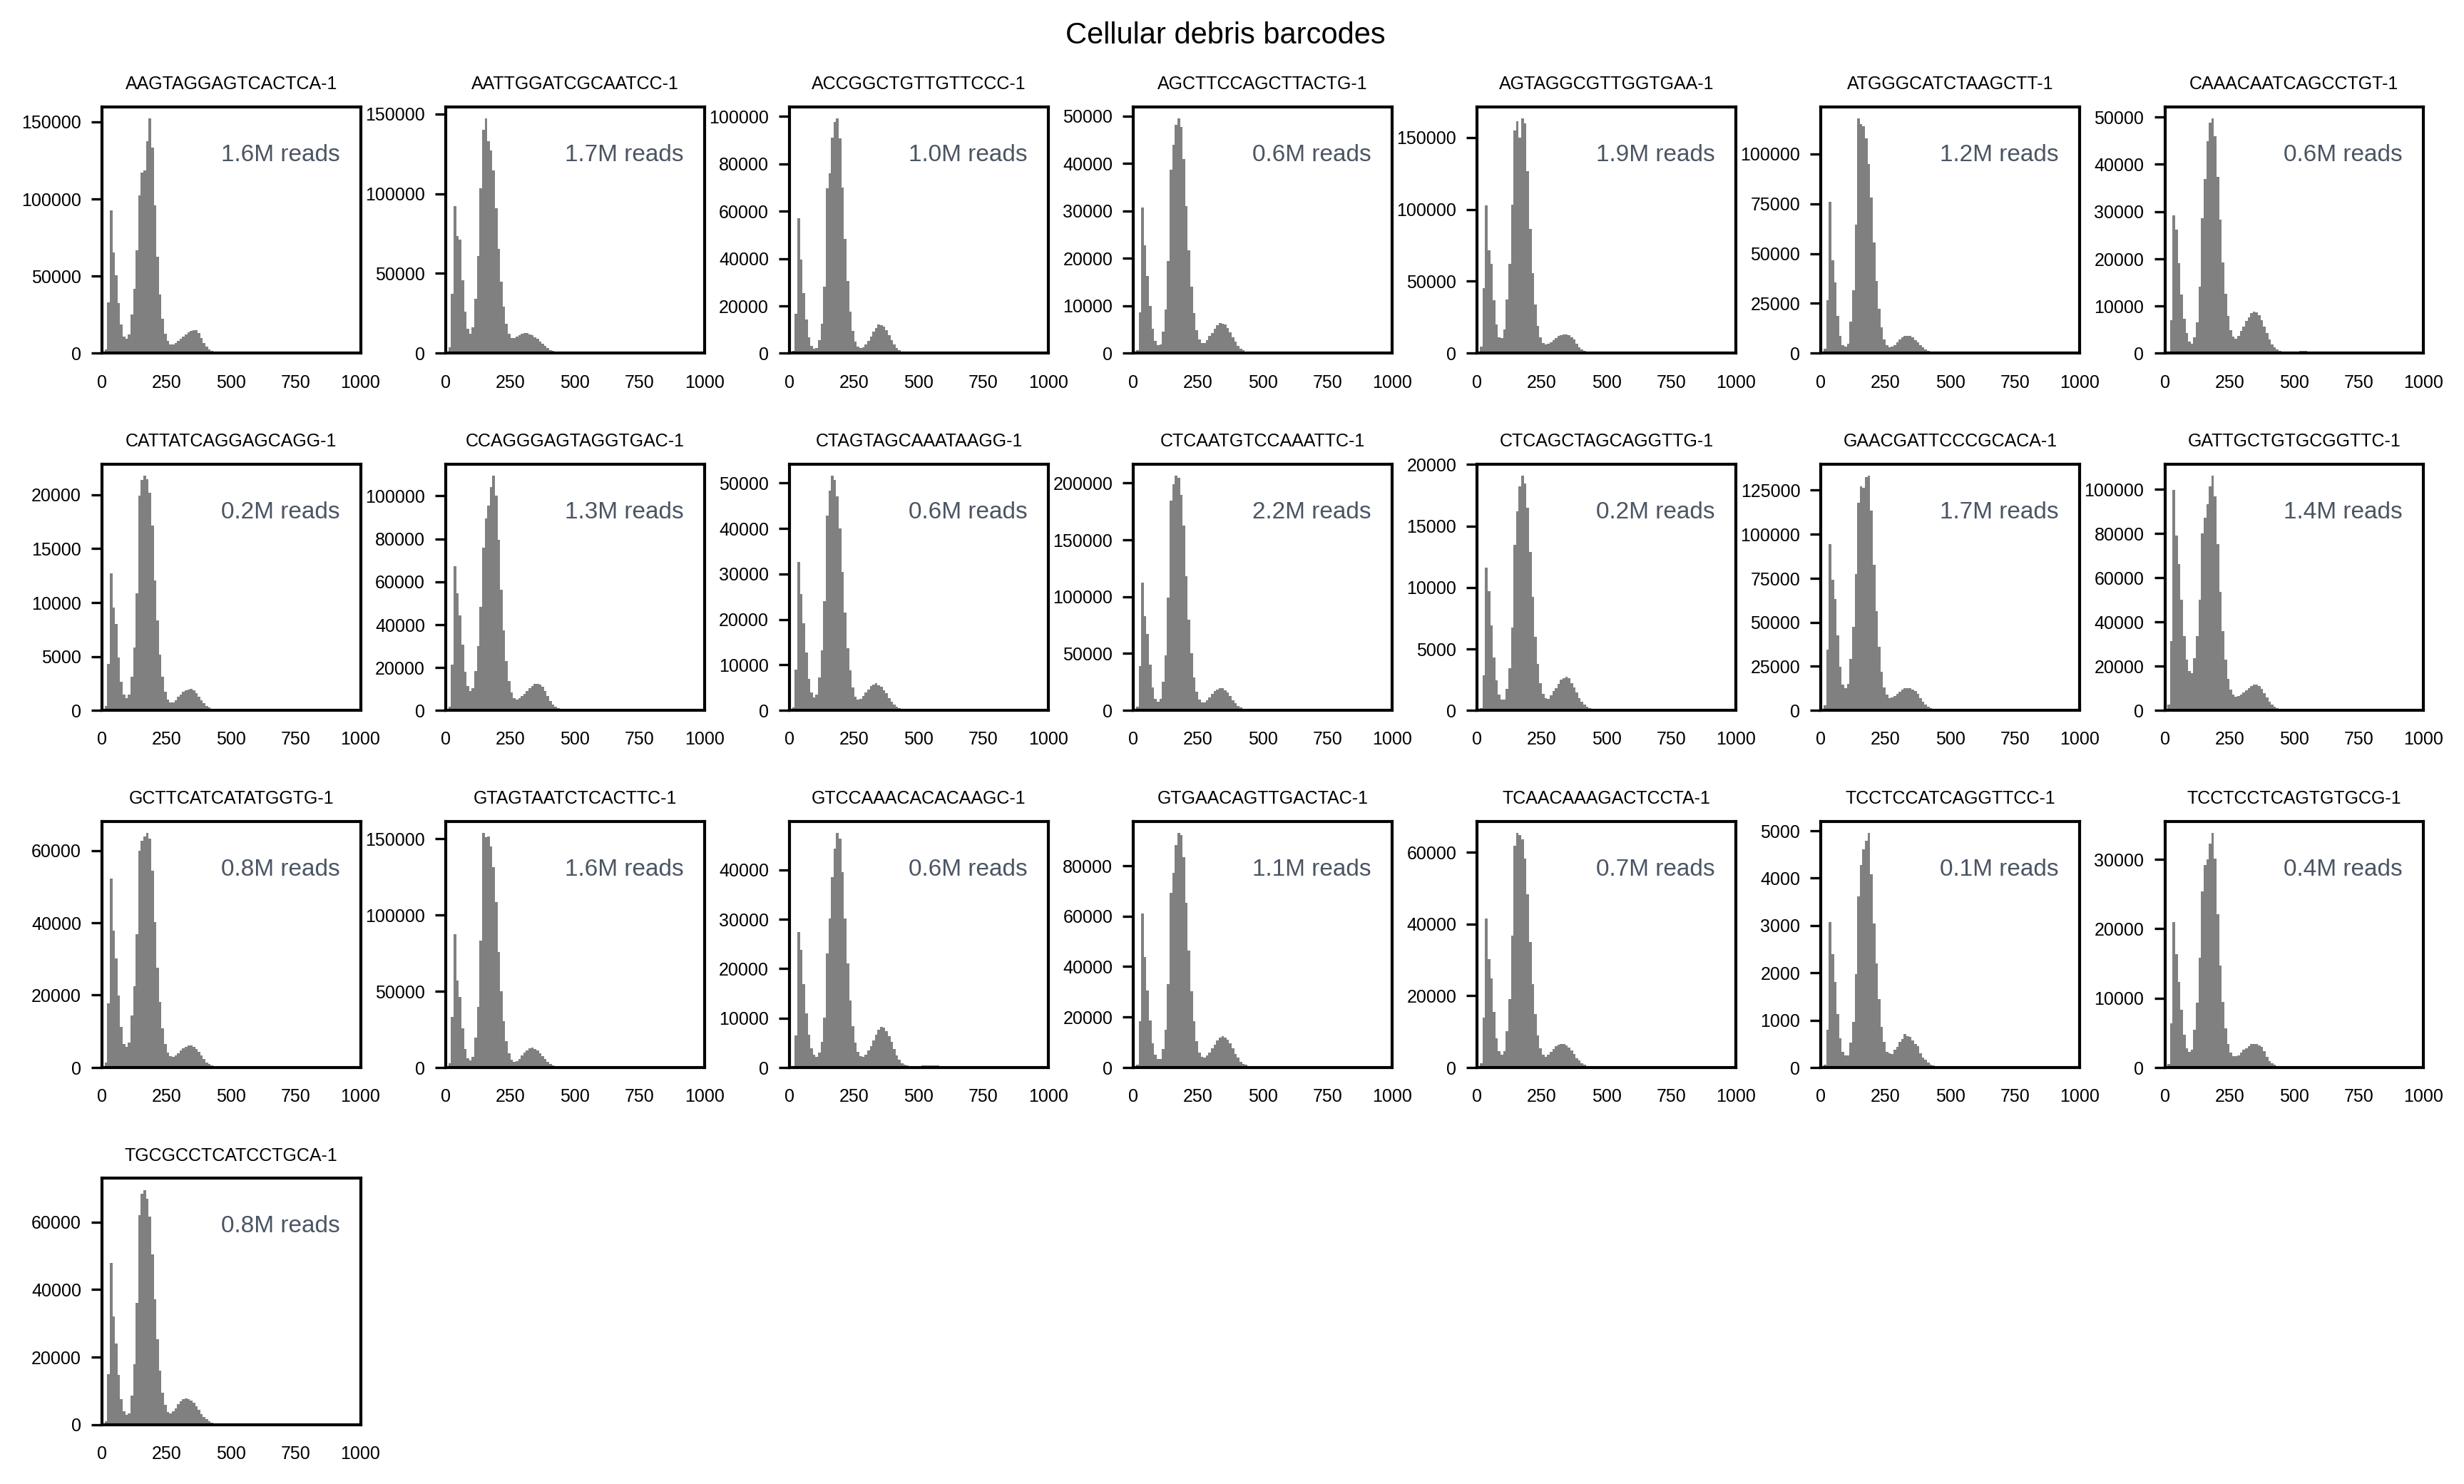

In [24]:
total_sub_fig = len(bc_DNAdebris_list)
ncol = 7
nrow = total_sub_fig//ncol + 1
fig, ax = plt.subplots(nrow, ncol, figsize=(14, 8), gridspec_kw={'wspace': 0.33, 'hspace': 0.45})
ax = ax.flatten()

for i, bc in enumerate(bc_DNAdebris_list):
    if i >= nrow*ncol:
        break
    s = frag.loc[frag['atac_bc'] == bc, 'frag_length']
    _ = ax[i].hist(s, bins=100, range=(0, 1000), color='grey')
    ax[i].set_xlim(0, 1000)
    ax[i].tick_params(axis='both', which='major', bottom=False,  labelsize=6)
    ax[i].set_title(bc + '-1',  fontsize=6)
    ax[i].text(0.92, 0.85, f'{len(s)/1e6:.1f}M reads', transform=ax[i].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')
for j in range(i+1, nrow*ncol):
    ax[j].axis('off')

fig.suptitle('Cellular debris barcodes', y=0.93, fontsize=10)

Text(0.5, 0.04, 'Chromosome Position')

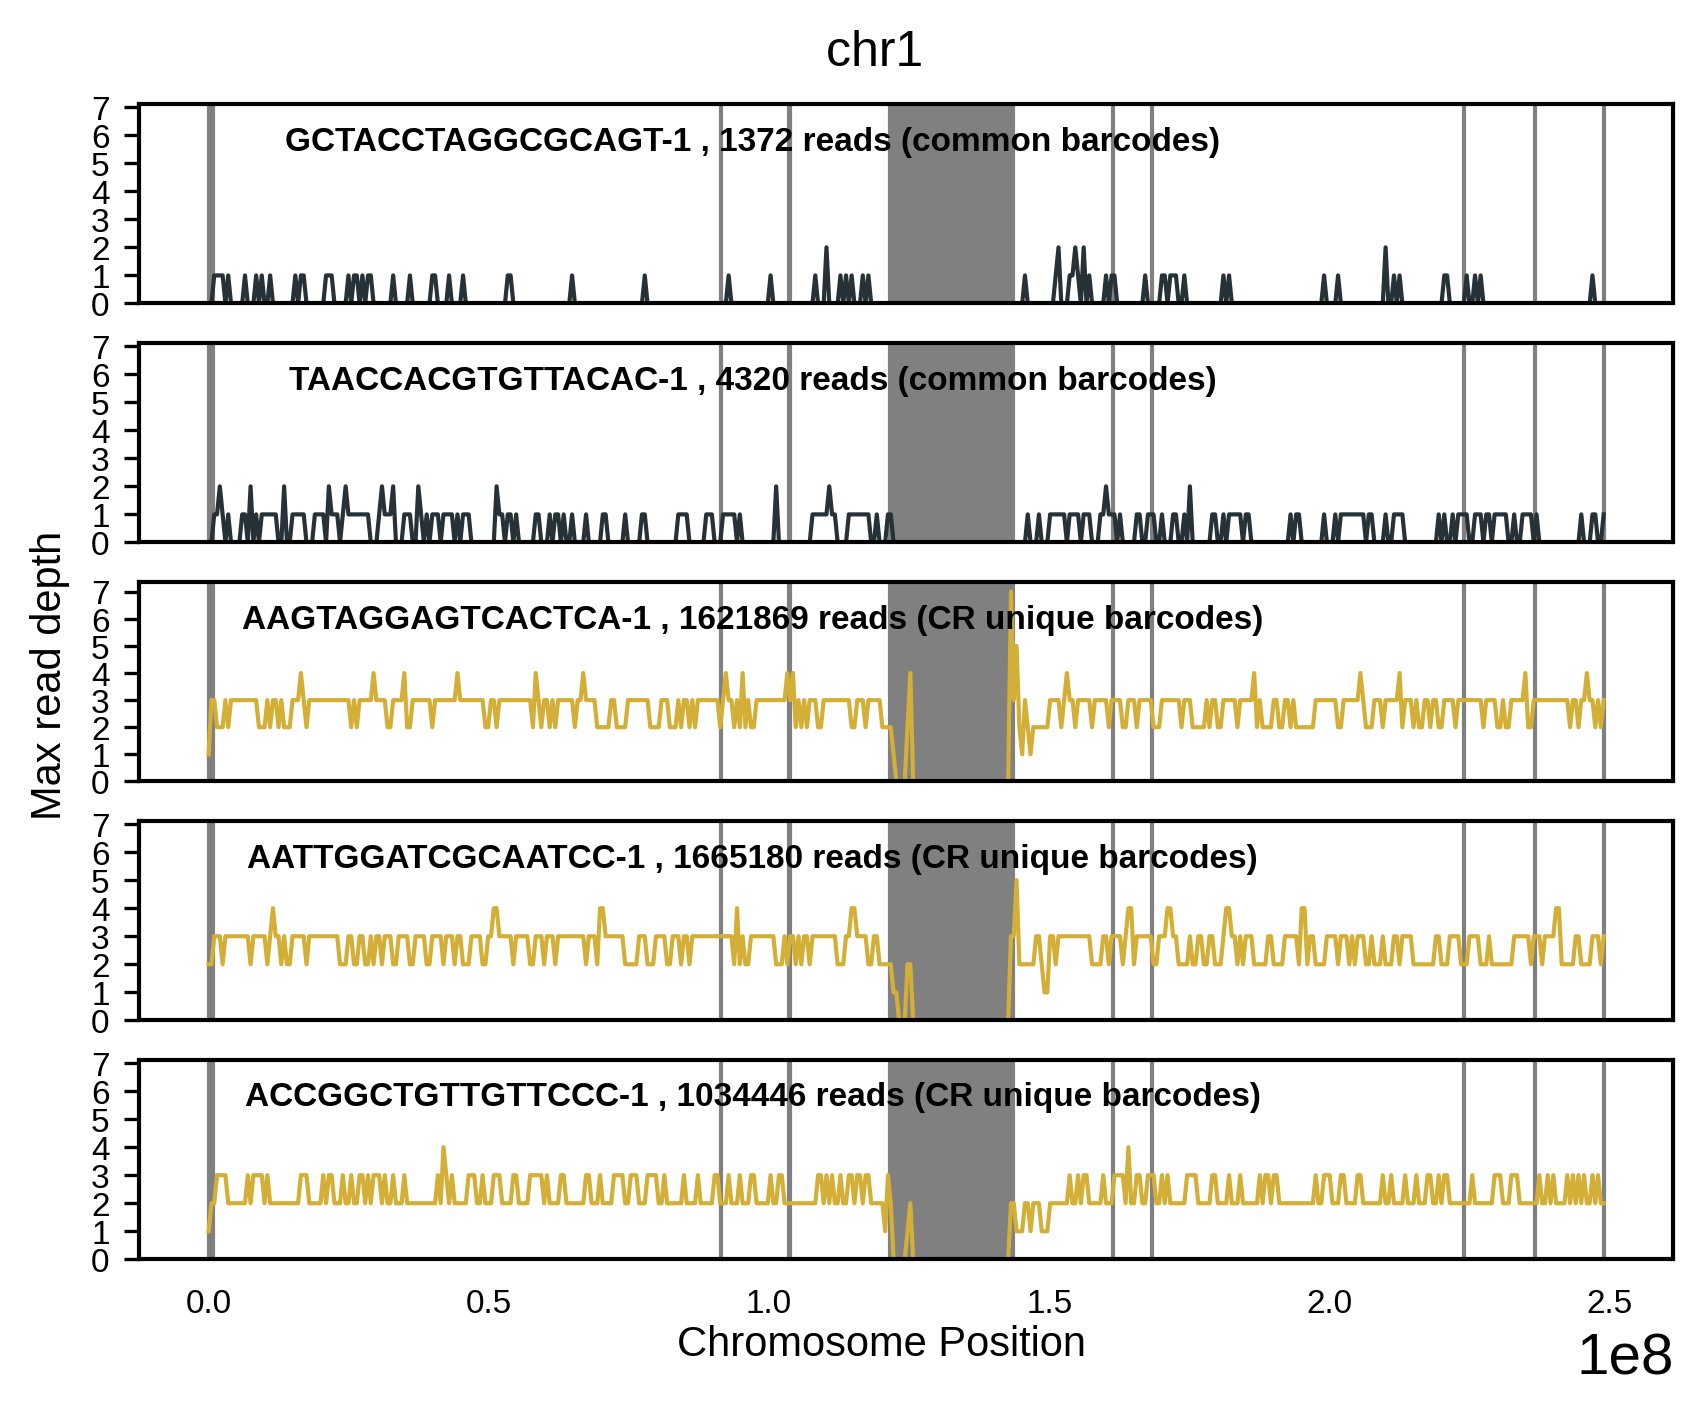

In [25]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=5, figsize=(6.6, 5), sharex=True)
ax = ax.flatten()

shown_methods = []
np.random.seed(999)  # For reproducibility
for i, bc in enumerate(list(np.random.choice(bc_common_list, size=2, replace=False))  + bc_DNAdebris_list):
    if i >= len(ax)  :
        break
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
    
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[i].plot(np.linspace(0, bc_chrom_size, bins), bc_binned_stats, label=bc, color=cat_colors_map.get(identified_method, 'grey'), linewidth=1)
    #ax[i].text(0.7, 0.8, f'#reads: {np.round(read_depth/1000, 1)}k', transform=ax[i].transAxes, ha='center', fontsize=10, color='black')
    ax[i].set_title(f'{bc}-1 , {read_depth} reads ({identified_method} barcodes)', fontsize=8,   pad=1, x=0.4, y=0.75, fontweight='bold')
    y_lim = max(ax[i].get_ylim()[1], 7.1)
    ax[i].set_ylim(0, y_lim)
    ax[i].set_yticks(np.arange(y_lim))
    ax[i].tick_params(axis='both', which='major', bottom=False,  labelsize=8)
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='grey', alpha=    1)
    bc_bw.close()



fig.suptitle(f'{chrom} ', y=0.93, fontsize=12)
fig.supylabel('Max read depth',fontsize=10,  x=0.07, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.04, )


Text(0.5, 0.07, 'Chromosome Position')

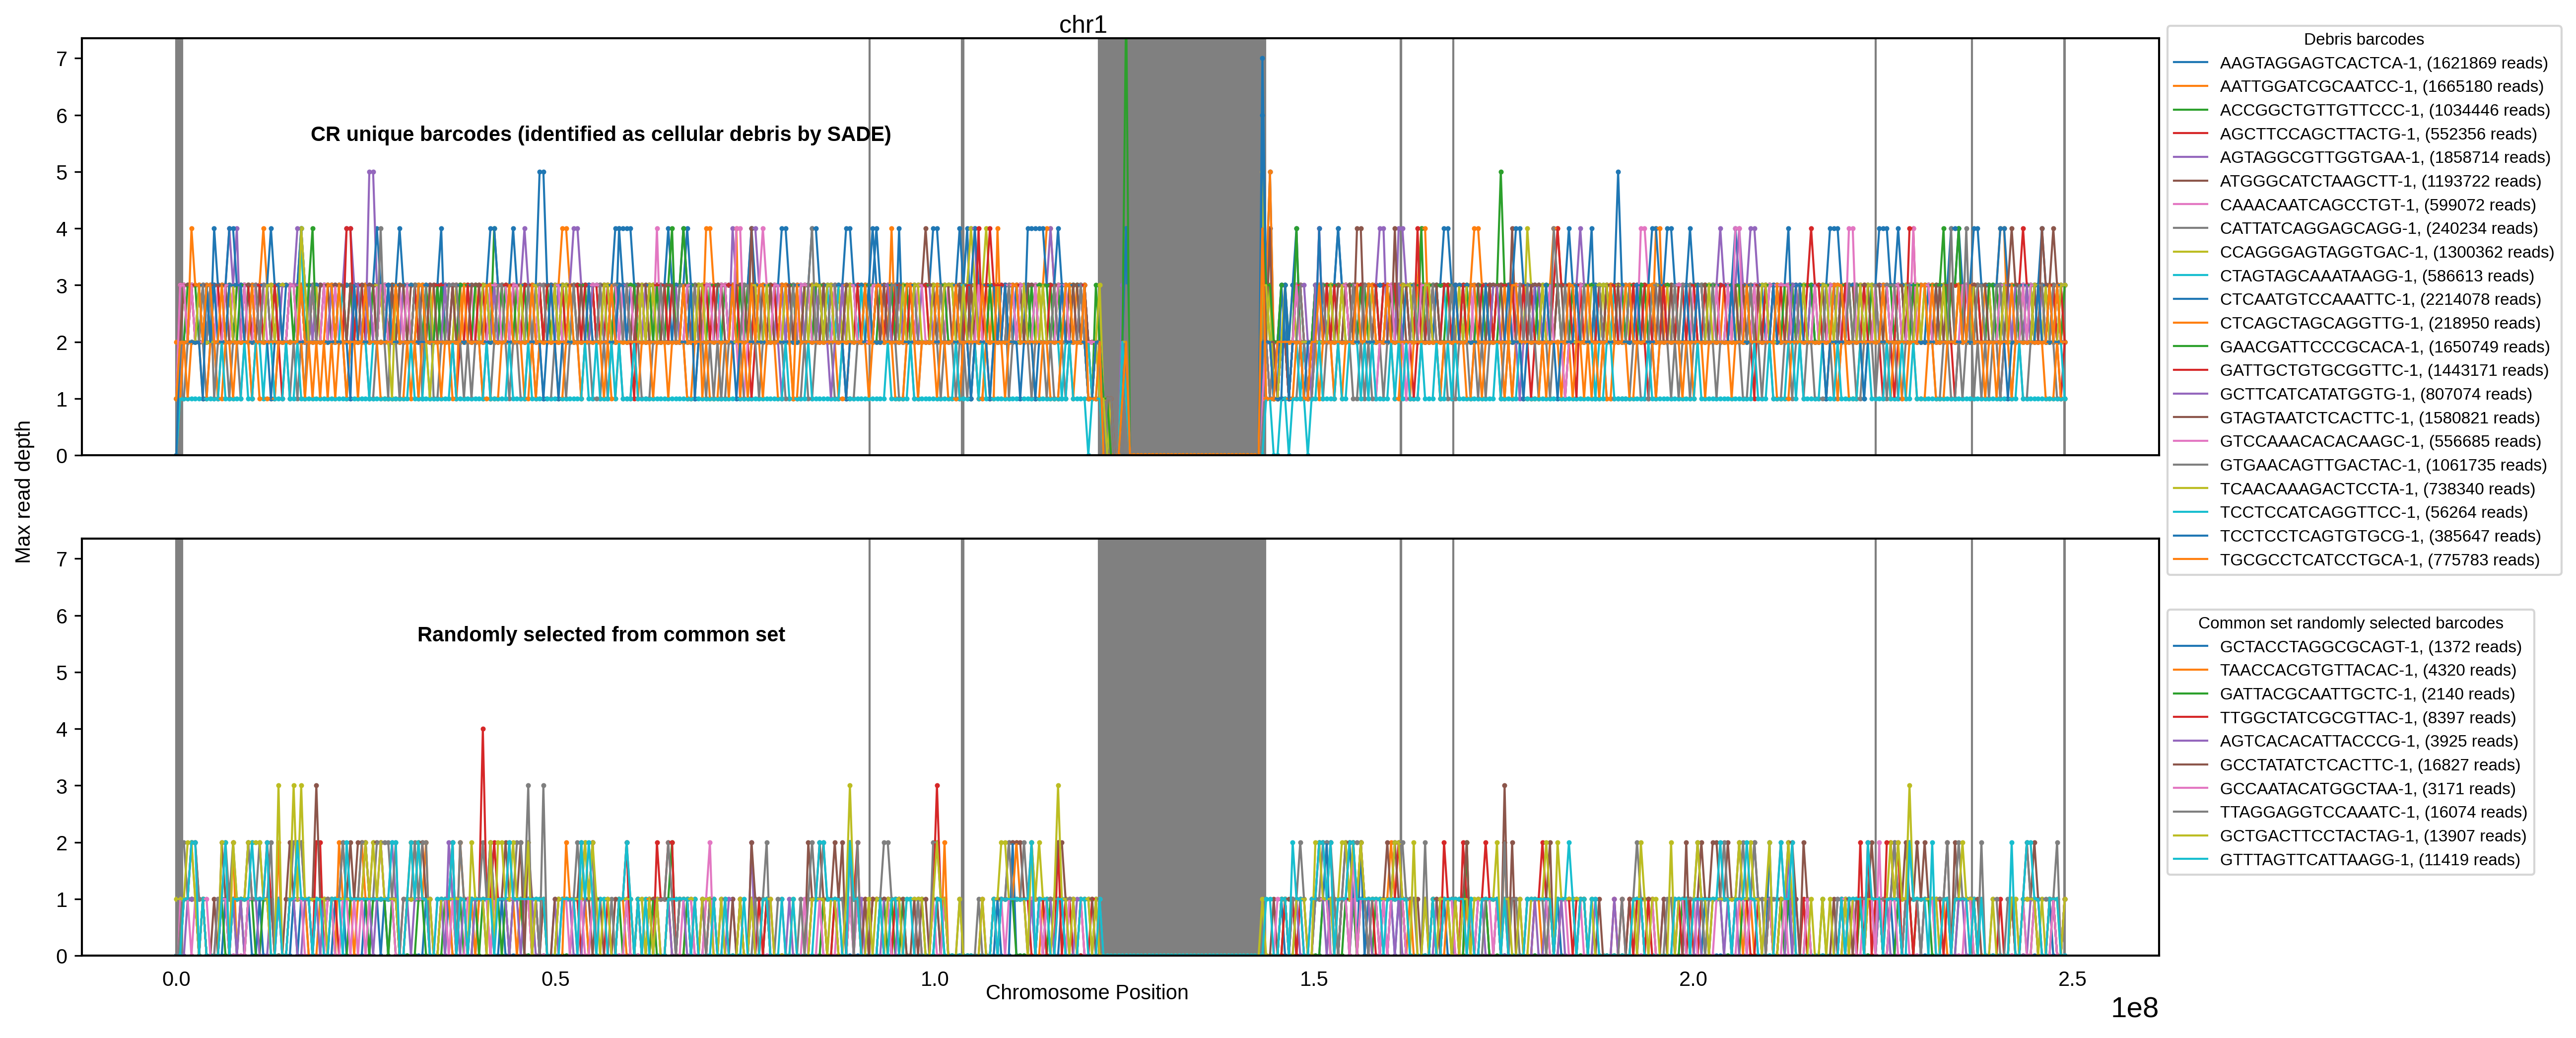

In [26]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=2, figsize=(18, 8), sharex=True)

for nr in range(len(ax)):
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[nr].axvspan(row['start'], row['end'], color='grey', alpha=1)
    bc_bw.close()

shown_methods = []
for i, bc in enumerate(bc_DNAdebris_list):
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
    
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[0].set_title(f'{identified_method} barcodes (identified as cellular debris by SADE)', fontsize=10,   pad=1, x=0.25, y=0.75, fontweight='bold')
    ax[0].plot(np.linspace(0, bc_chrom_size, bins), bc_binned_stats, linewidth=1, label=f'{bc}-1, ({read_depth} reads)')
    ax[0].scatter(np.linspace(0, bc_chrom_size, bins), bc_binned_stats, s=2)
    y_lim = max(ax[0].get_ylim()[1], 2)
    ax[0].set_ylim(0, y_lim)
    ax[0].set_yticks(np.arange(y_lim))
    ax[0].tick_params(axis='both', which='major', bottom=False,  labelsize=10)

global_y_lim = y_lim

np.random.seed(999)  # For reproducibility
for i, bc in enumerate(np.random.choice(bc_common_list, size=10, replace=False)):

    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
        
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[-1].plot(np.linspace(0, bc_chrom_size, bins), np.array(bc_binned_stats) ,  linewidth=1,
               label=f'{bc}-1, ({read_depth} reads)')
    ax[-1].scatter(np.linspace(0, bc_chrom_size, bins), np.array(bc_binned_stats) , s=2)

    y_lim = max(ax[-1].get_ylim()[1], 2.1, global_y_lim) # to show value at 2.
    ax[-1].set_title('Randomly selected from common set', fontsize=10,   pad=1, x=0.25, y=0.75, fontweight='bold')
    ax[-1].set_ylim(0, y_lim)
    ax[-1].set_yticks(np.arange(y_lim))
    ax[-1].tick_params(axis='both', which='major', bottom=False,  labelsize=10)

for nr in range(len(ax)):
    ax[nr].legend(loc='upper left', bbox_to_anchor=(1., 1.05 - nr * .2), title=f'{"Debris barcodes" if nr == 0 else "Common set randomly selected barcodes"}', fontsize=8, title_fontsize=8,
                  ncol=1 if nr == 0 else 1)
fig.suptitle(f'{chrom} ', y=0.9, fontsize=12)
fig.supylabel('Max read depth',fontsize=10,  x=0.1, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.07, )


# See method unique barcode's fragment length distribution

In [27]:
frag_tss = frag.loc[frag['atac_bc'].isin(bc_tss_only_list), 'frag_length']
frag_tss.shape

(249811,)

In [28]:
frag_entropy = frag.loc[frag['atac_bc'].isin(bc_entropy_only_list), 'frag_length']
frag_entropy.shape

(128843,)

In [29]:
frag_cr = frag.loc[frag['atac_bc'].isin(bc_cr_only_list), 'frag_length']
frag_cr.shape

(22226860,)

In [30]:
frag_common = frag.loc[frag['atac_bc'].isin(bc_common_list), 'frag_length']
frag_common.shape

(18205206,)

In [31]:
frag_TSS_CR = frag.loc[frag['atac_bc'].isin(bc_CRnTSS_list), 'frag_length']
frag_TSS_CR.shape

(68217,)

In [32]:
frag_SADE_CR = frag.loc[frag['atac_bc'].isin(bc_SADEnCR_list), 'frag_length']
frag_SADE_CR.shape

(2788597,)

In [33]:
frag_SADE_TSS = frag.loc[frag['atac_bc'].isin(bc_SADEnTSS_list), 'frag_length']
frag_SADE_TSS.shape

(323640,)

In [34]:
for n, s in zip(['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR'], 
          [frag_common, frag_entropy, frag_cr, frag_tss, frag_TSS_CR, frag_SADE_CR, frag_SADE_TSS]):
    s.name = n

total_bc_counts = {}
for n, l in zip(['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR'], 
      [bc_common_list, bc_entropy_only_list, bc_cr_only_list, bc_tss_only_list, bc_CRnTSS_list, bc_SADEnCR_list, bc_SADEnTSS_list]):
      total_bc_counts[n] = len(l)

/tmp/ipykernel_1453605/1569912987.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


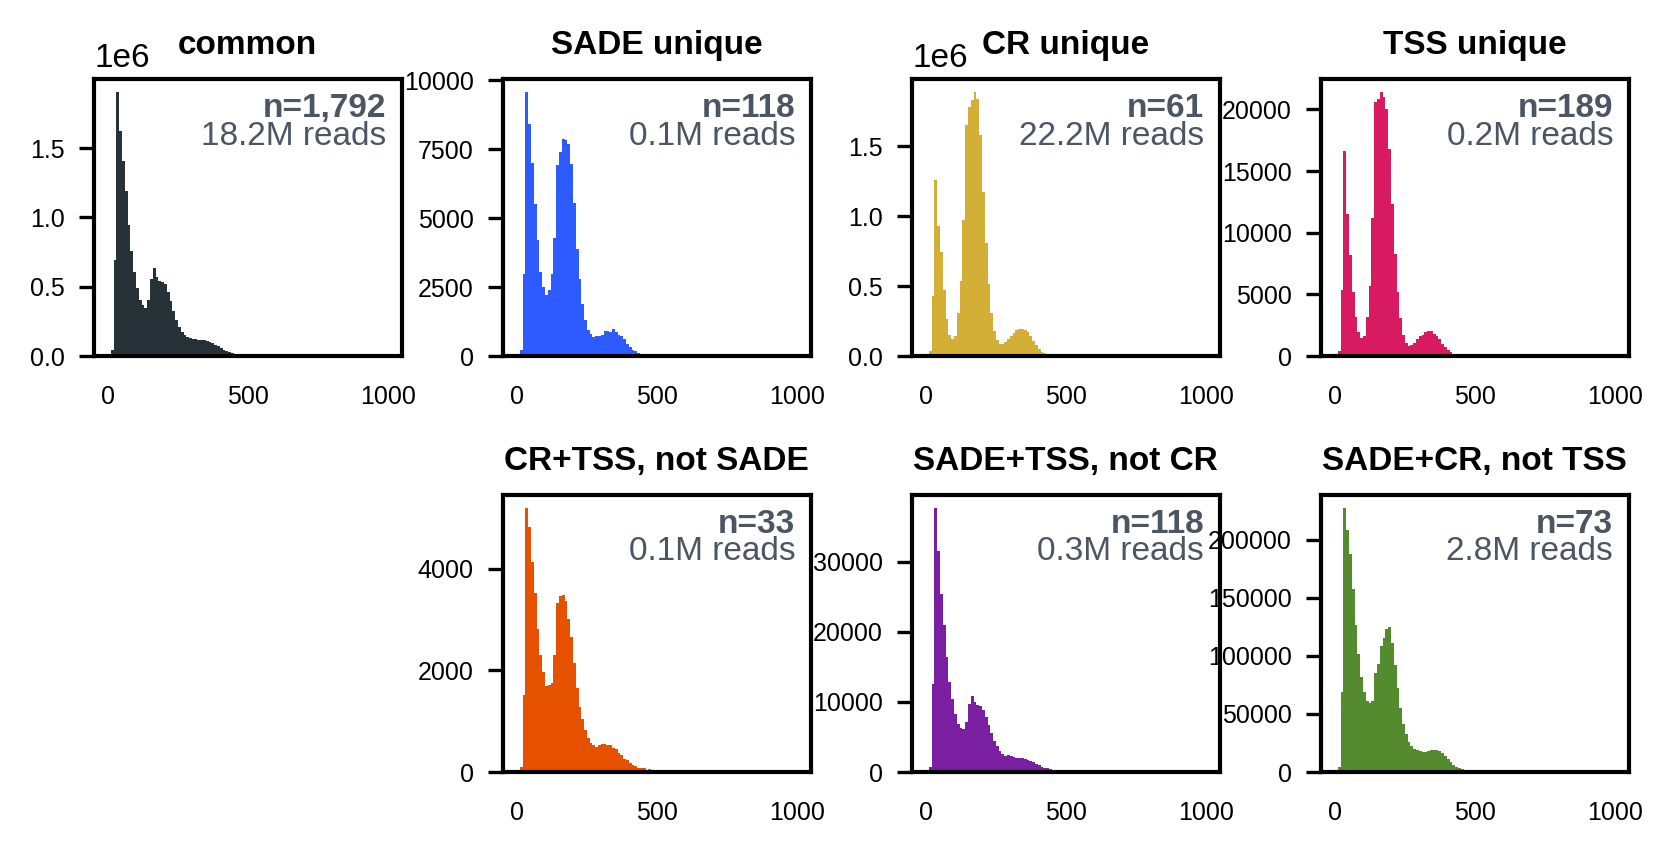

In [35]:
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(6.6,3), gridspec_kw={'wspace': 0.33, 'hspace': 0.5})
ax = ax.flatten()
for s, i  in zip([frag_common, frag_entropy, frag_cr, frag_tss, None,  frag_TSS_CR, frag_SADE_TSS, frag_SADE_CR], range(8)):
    if s is None:
        ax[i].axis('off')
        continue
    _ = ax[i].hist(s, bins=100, range=(0, 1000), color=cat_colors_map.get(s.name, 'grey'), )
    ax[i].set_title(s.name, fontweight='bold', fontsize=8)
    ax[i].yaxis.get_offset_text().set_fontsize(8)
    ax[i].tick_params(axis='both', which='major', bottom=False,  labelsize=6)
    ax[i].text(0.95, 0.95, f'n={total_bc_counts.get(s.name, 0):,}', transform=ax[i].transAxes, ha='right', va='top', fontsize=8, color='#4B5563', fontweight='bold')
    ax[i].text(0.95, 0.85, f'{len(s)/1e6:.1f}M reads', transform=ax[i].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')

fig.tight_layout()

## Track vis 

### Regions  
IL7R  chr5:35,854,891-35,881,603  
LEF1 chr4:108,045,548-108,170,932  
LYZ chr12:69,346,381-69,356,234  
GNB1  chr1:1,783,286-1,893,087

In [36]:
# reads for each complete filtered droplet set 
eachset_identified_bw_subdir = os.path.join(Union_cell_subdir, 'cmp_3Set', 'filtering_method_set')
eachset_bw_files = {}
for n in ['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS',]:
    file_name = f'sorted_farg_{n}.bw'
    eachset_bw_files[n] = os.path.join(eachset_identified_bw_subdir, file_name)

# Union set with SADE and CR filtered droplets and reads subset corresponding to the droplet intersection of SADE and CR
subset_cmp_SC_bw_sudir = os.path.join(Union_cell_subdir, 'cmp_SC')
subset_cmp_SC_bw_files = {}
for n in ['cr_only', 'entropy_only', 'common']:
    file_name = f'{n}_bc_fragments.bw'
    subset_cmp_SC_bw_files[n] = os.path.join(subset_cmp_SC_bw_sudir, file_name)

# Union set among SADE, CR and TSS with 7 categories of droplets and reads subset corresponding to the droplet intersection of SADE, CR and TSS
set_identified_bw_subdir = os.path.join(Union_cell_subdir, 'cmp_3Set')
set_bw_files = {}
for n in ['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR']:
    file_name = f'sorted_farg_{n.replace(" ", "_", -1).replace(",", "_")}.bw'
    set_bw_files[n] = os.path.join(set_identified_bw_subdir, file_name)

debris_set_bw_subdir = os.path.join(Union_cell_subdir, 'cmp_DNAdebris_entropy')
debris_set_bw_files = {}
for n in ['DNAdebris', 'NotDNAdebris']:
    file_name = f'{n}_fragments.CPM.bw'
    debris_set_bw_files[n] = os.path.join(debris_set_bw_subdir, file_name)



/tmp/ipykernel_1453605/4112704396.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)


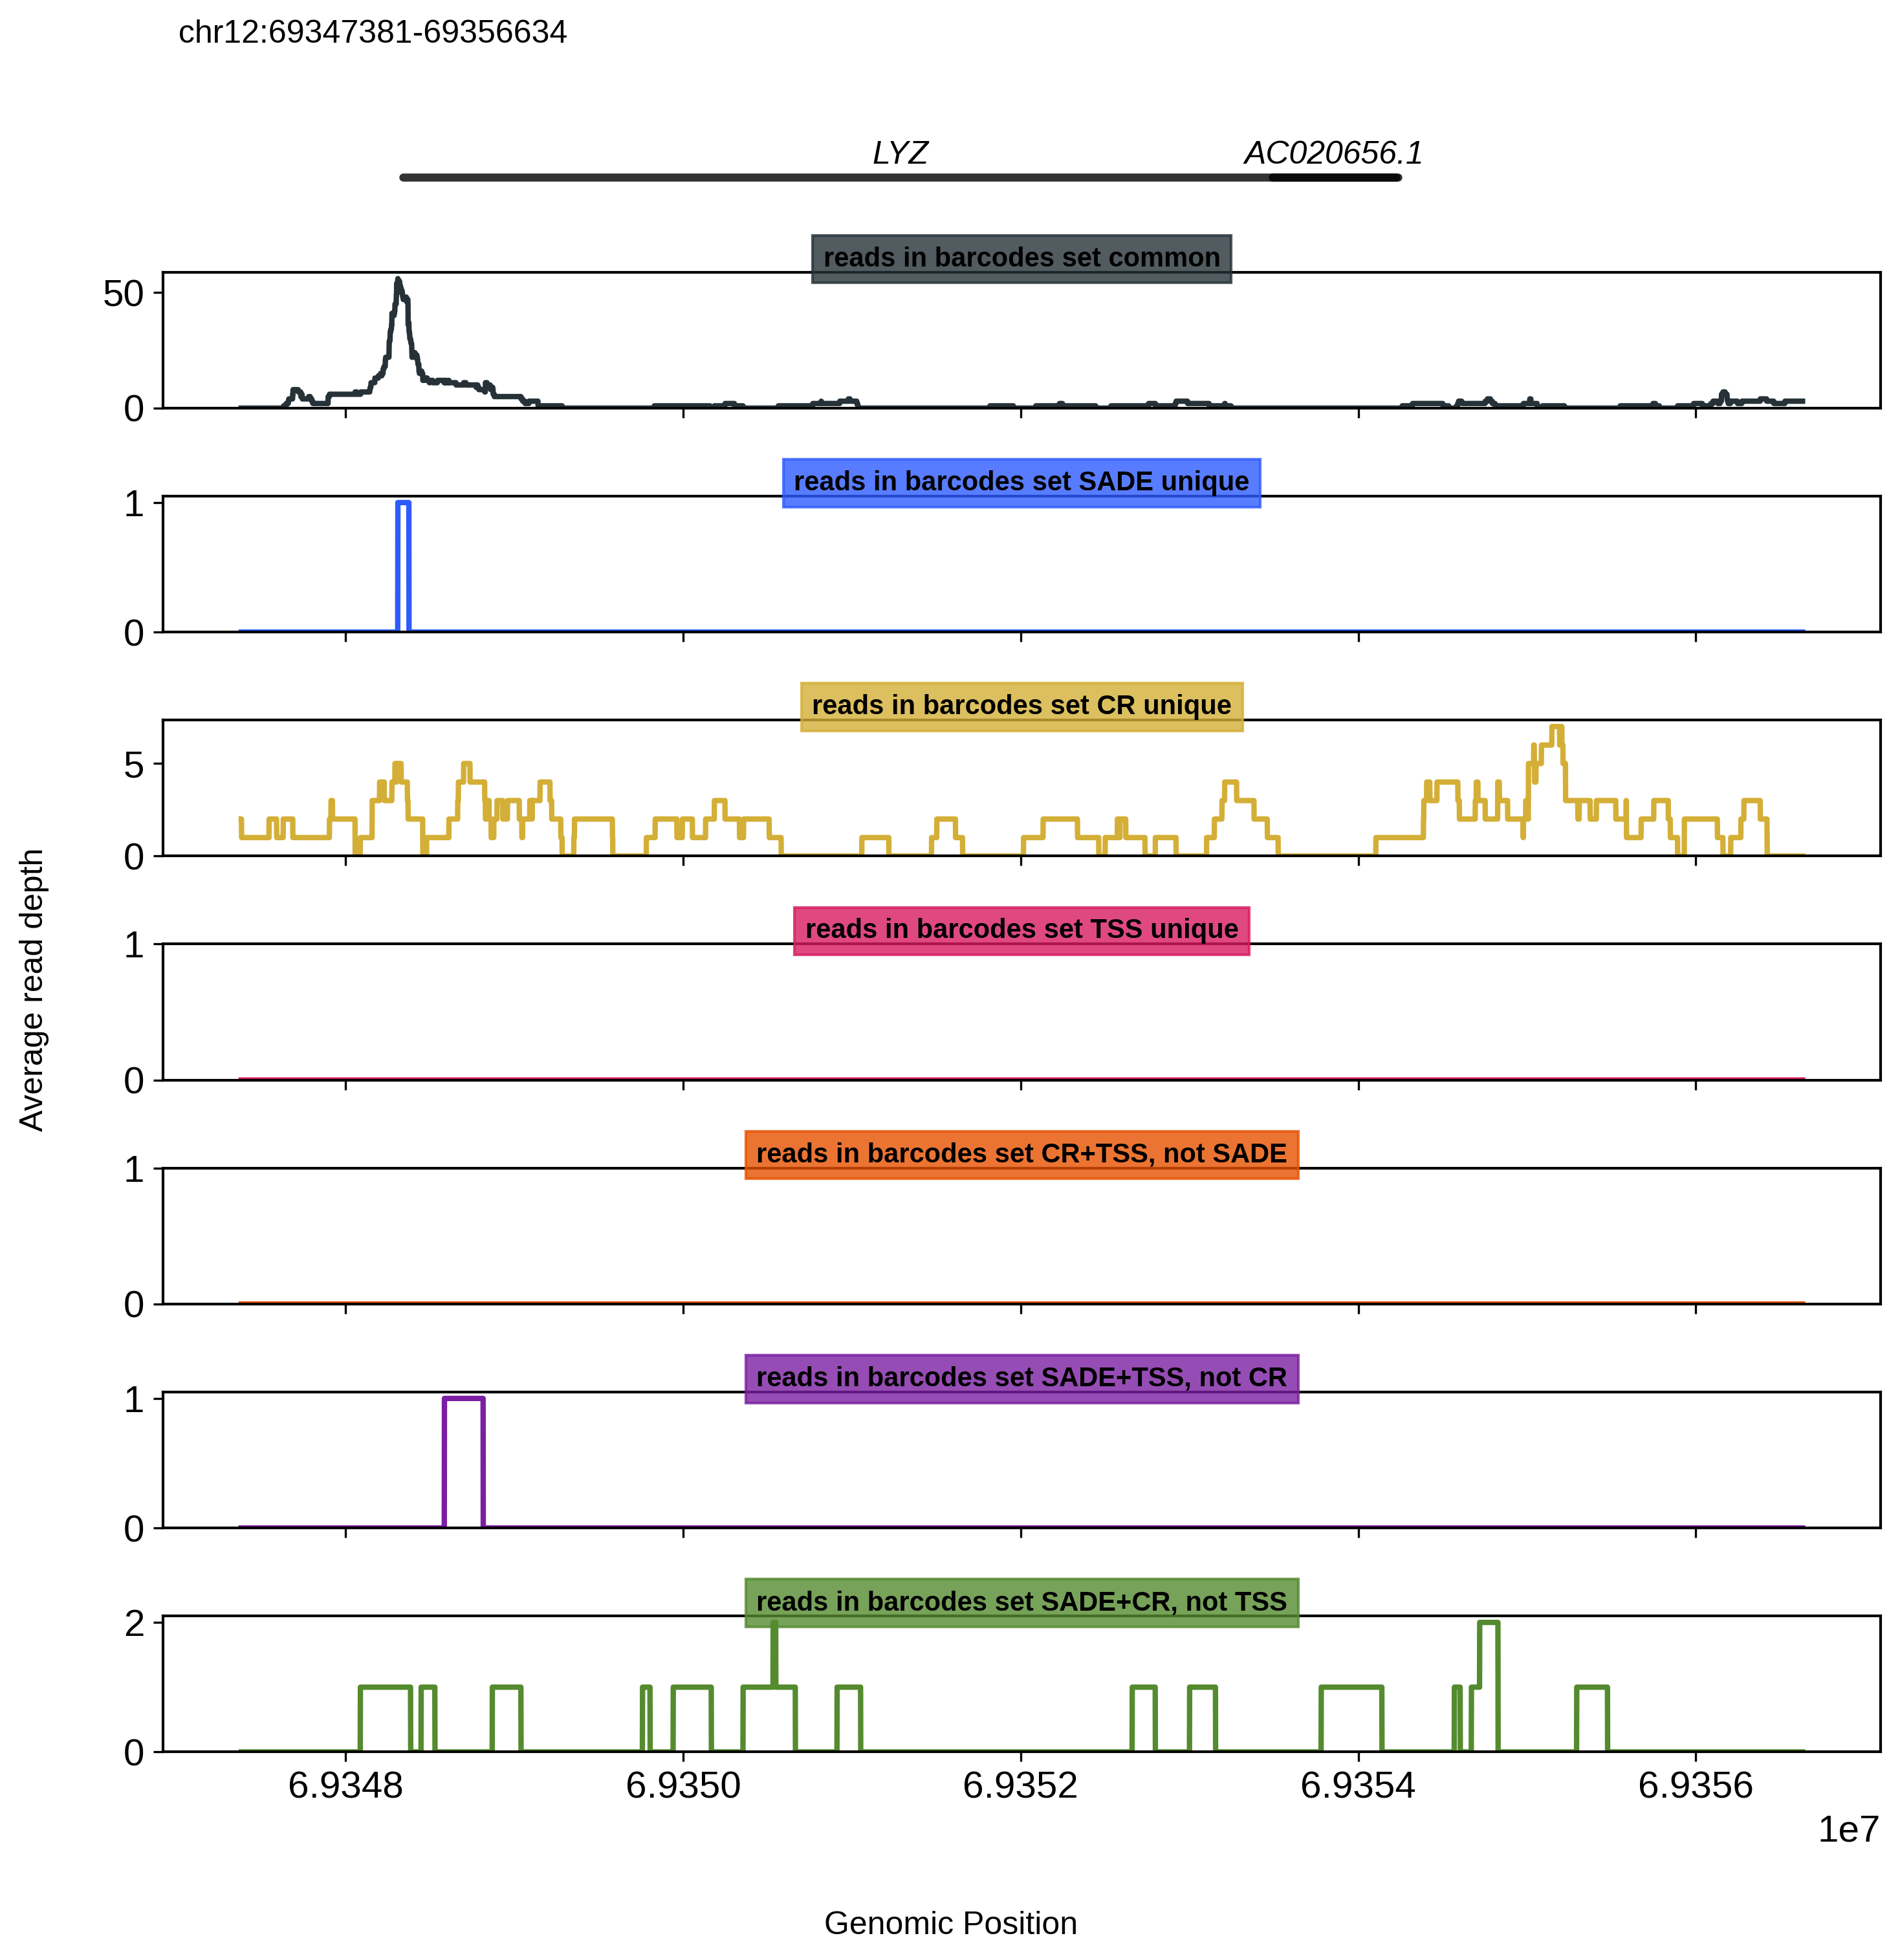

In [37]:

chrom = "chr12"
start = 69347381
end = 69356634
ratios = [0.1] + [1] * len(set_bw_files)

fig, ax = plt.subplots( nrows=8,  ncols=1, figsize=(10, 10), sharex=True, 
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

for j, s in enumerate(unique_categories):
    i = j + 1
    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
    values = np.nan_to_num(values, nan=0.0)
    ax[i].plot(range(start, end), values, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)
    y_lim = max(ax[i].get_ylim()[1], 1)
    ax[i].set_ylim(0, y_lim)
    
    bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [1, 1],  lw=3,color='black',solid_capstyle='round', alpha=0.8)
    ax[0].text((gene.start + gene.end)/2, 1.3, gene.gene_name, 
                ha='center', va='top', fontsize=12, fontstyle='italic')

# handles = [mpatches.Patch(color=cat_colors_map[s], label=s) for s in set_bw_files.keys()]
# fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 0.9), title='Identified by', fontsize=10)

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=1, fontsize=12,)
fig.supxlabel("Genomic Position", fontsize=12)
fig.supylabel("Average read depth", fontsize=12)
fig.tight_layout()

Text(0.5, 0.08, 'Chromosome Position')

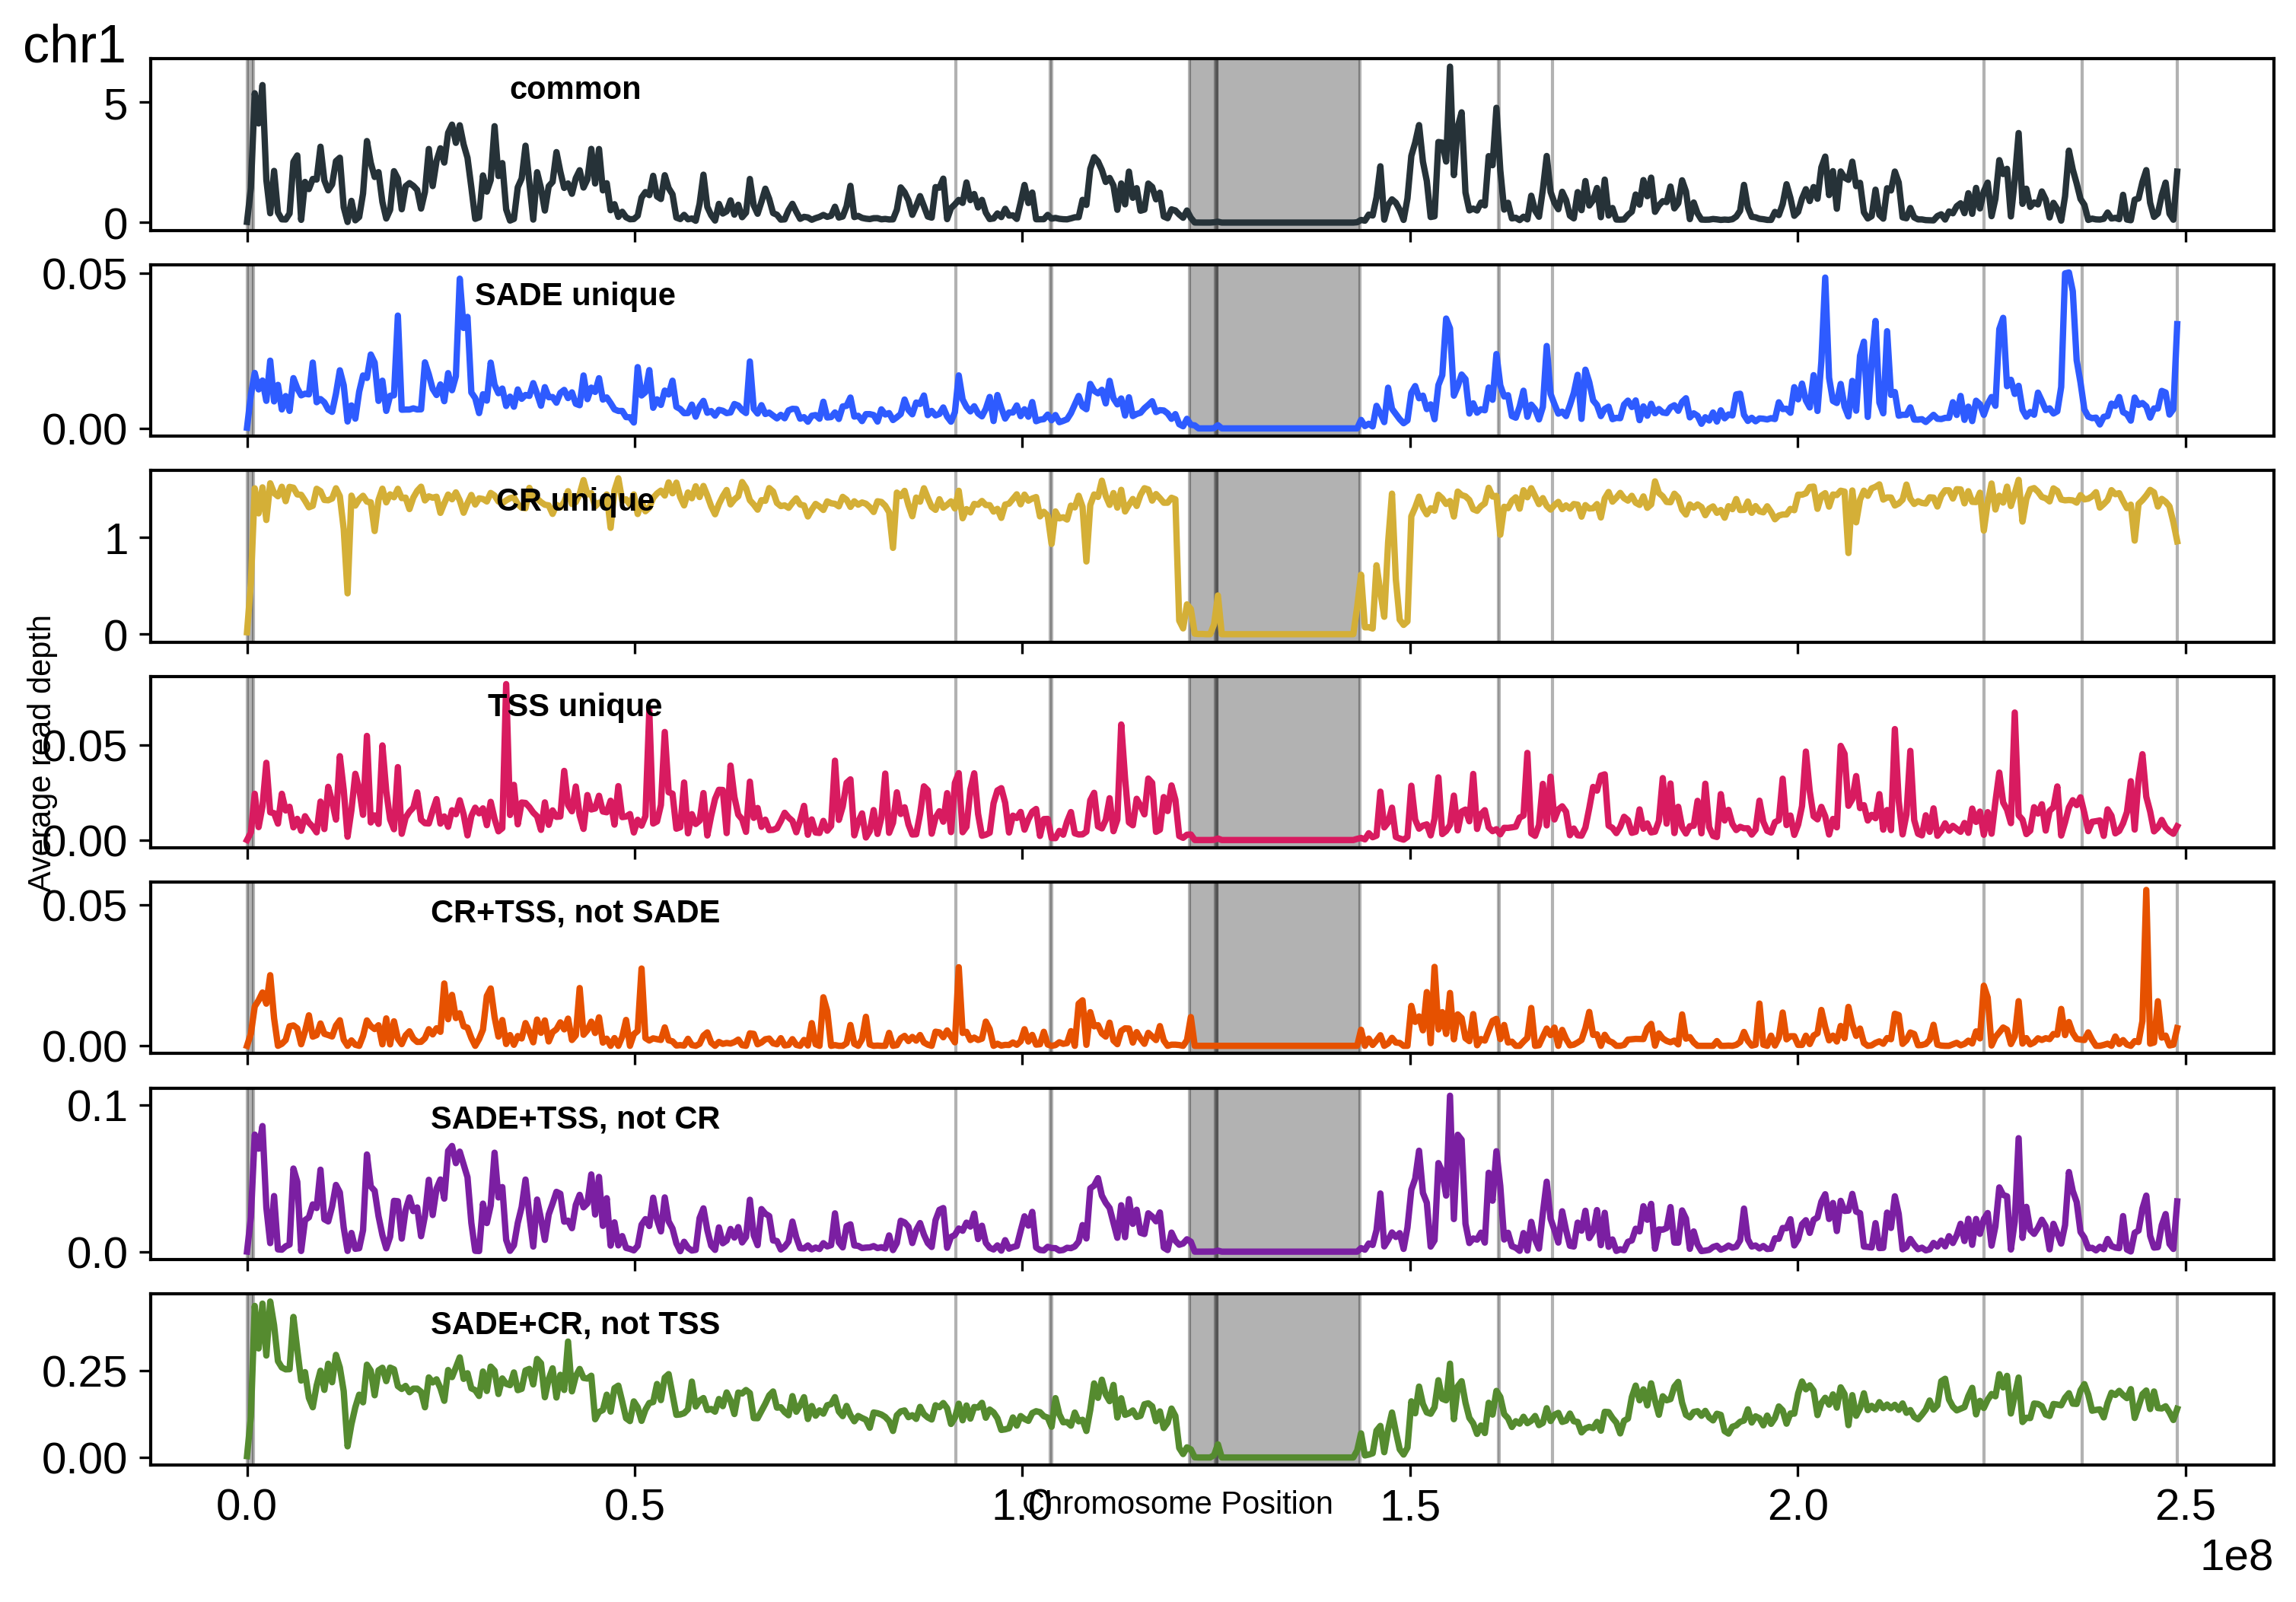

In [38]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=7, figsize=(12, 8), sharex=True, sharey=False)
ax = ax.flatten()


for i, s in enumerate(unique_categories):

    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    bw_chrom_size = bw.chroms(chrom)
    bw_binned_stats = bw.stats(chrom, 0, bw_chrom_size, nBins=bins, type="mean")


    ax[i].plot(np.linspace(0, bw_chrom_size, bins), bw_binned_stats, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'{s}', fontsize=10,   pad=1, x=0.2, y=0.75, fontweight='bold')
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='black', alpha=0.3)
    bc_bw.close()



fig.suptitle(f'{chrom} ', y=0.9, x=0.1)
fig.supylabel('Average read depth',fontsize=10,  x=0.08, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.08, )


# Each filtering nuclei set 

Text(0.5, 0.52, 'Fragments length')

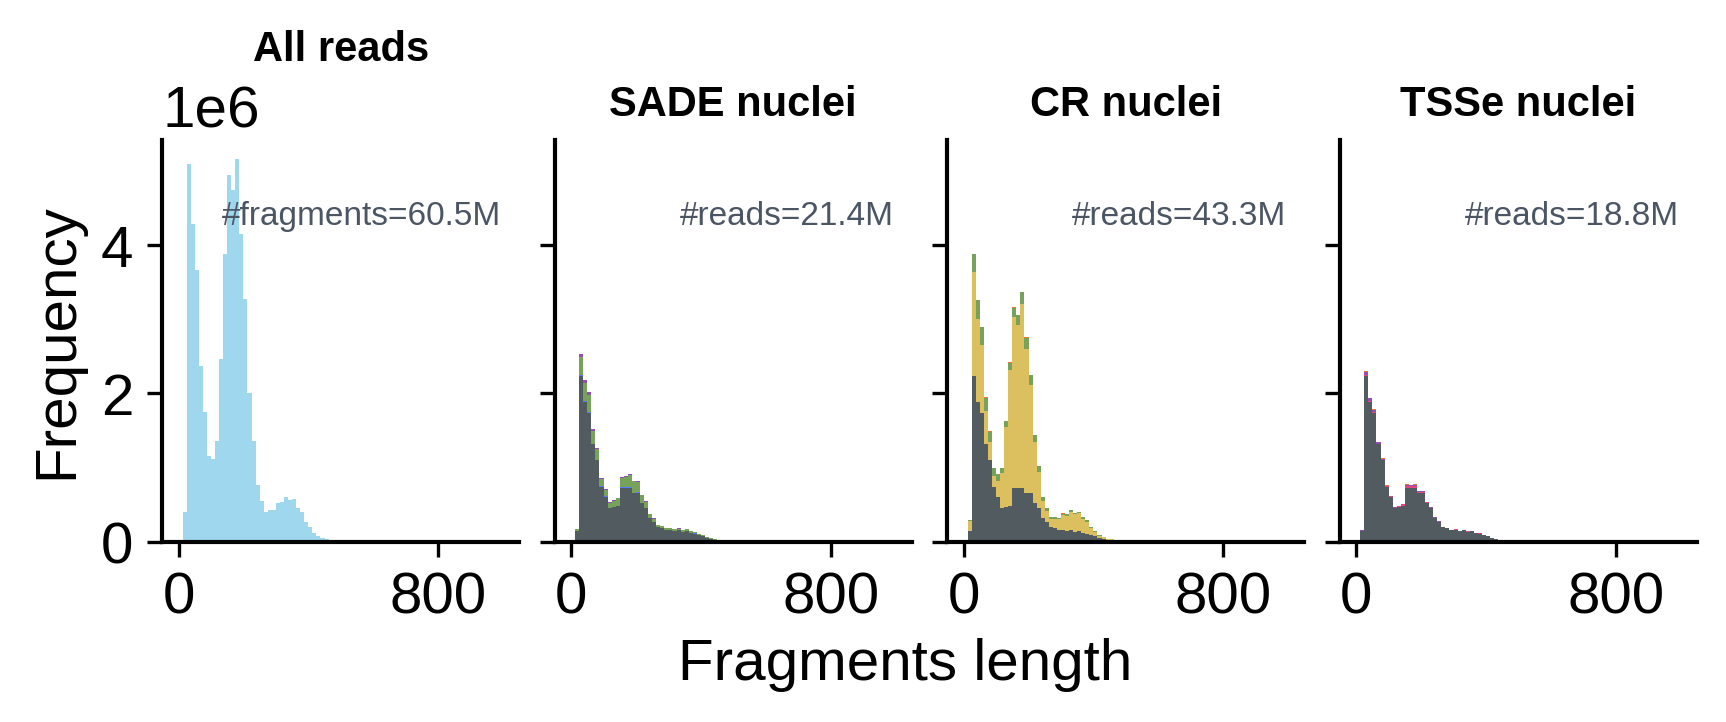

In [39]:
sade_nuclei_frag = [frag_common, frag_entropy, frag_SADE_CR, frag_SADE_TSS]
cr_nuclei_frag = [frag_common, frag_cr, frag_SADE_CR, frag_TSS_CR]
tss_nuclei_frag = [frag_common, frag_tss, frag_SADE_TSS, frag_TSS_CR]
all_reads = [frag['frag_length']]

sade_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'SADE unique', 'SADE+CR, not TSS', 'SADE+TSS, not CR']]
cr_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'CR unique', 'SADE+CR, not TSS', 'CR+TSS, not SADE']]
tss_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'TSS unique', 'SADE+TSS, not CR', 'CR+TSS, not SADE']]
all_reads_colors = ['green']

fig = plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1,1.5], hspace=0.3)


gs1 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], width_ratios=[1, 1, 1, 1], wspace=0.1)
ax0 = fig.add_subplot(gs1[0])
_ax = [fig.add_subplot(gs1[i], sharey=ax0) for i in range(1, 4)]
ax = [ax0] + _ax



# All reads 
ax[0].hist(all_reads, bins=80, range=(0, 1000), color='skyblue', alpha=0.8, edgecolor='none')
ax[0].text(0.95, 0.85, f'#fragments={len(frag) / 1e6:.1f}M', transform=ax[0].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')
ax[0].set_title('All reads', fontweight='bold', fontsize=10)
ax[0].set_xticks([0, 800])
ax[0].spines[['top', 'right']].set_visible(False)

for s, c, t, i in zip([sade_nuclei_frag, cr_nuclei_frag, tss_nuclei_frag], 
                   [sade_colors, cr_colors, tss_colors],
                   ['SADE', 'CR', 'TSSe'], 
                   range(1, 4)):
    _ = ax[i].hist(s, bins=80, range=(0, 1000), stacked=True, color=c, alpha=0.8, edgecolor='none')
    ax[i].set_title(f"{t} nuclei", fontweight='bold', fontsize=10)
    ax[i].set_xticks([0, 800])
    ax[i].text(0.95, 0.85, f'#reads={np.sum([len(frag) for frag in s]) / 1e6:.1f}M', 
               transform=ax[i].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='y', which='major',  labelleft=False)


# ax[4].axis('off')
# handles = [mpatches.Patch(color=cat_colors_map[s], label=s) for s in unique_categories] 
# ax[4].legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(0, 1.2) )

ax[0].set_ylabel('Frequency')
fig.text(0.5, 0.52, 'Fragments length', ha='center')#, fontweight='bold')


Text(0.3, 0.01, 'Genomic position on chr12 (bp)')

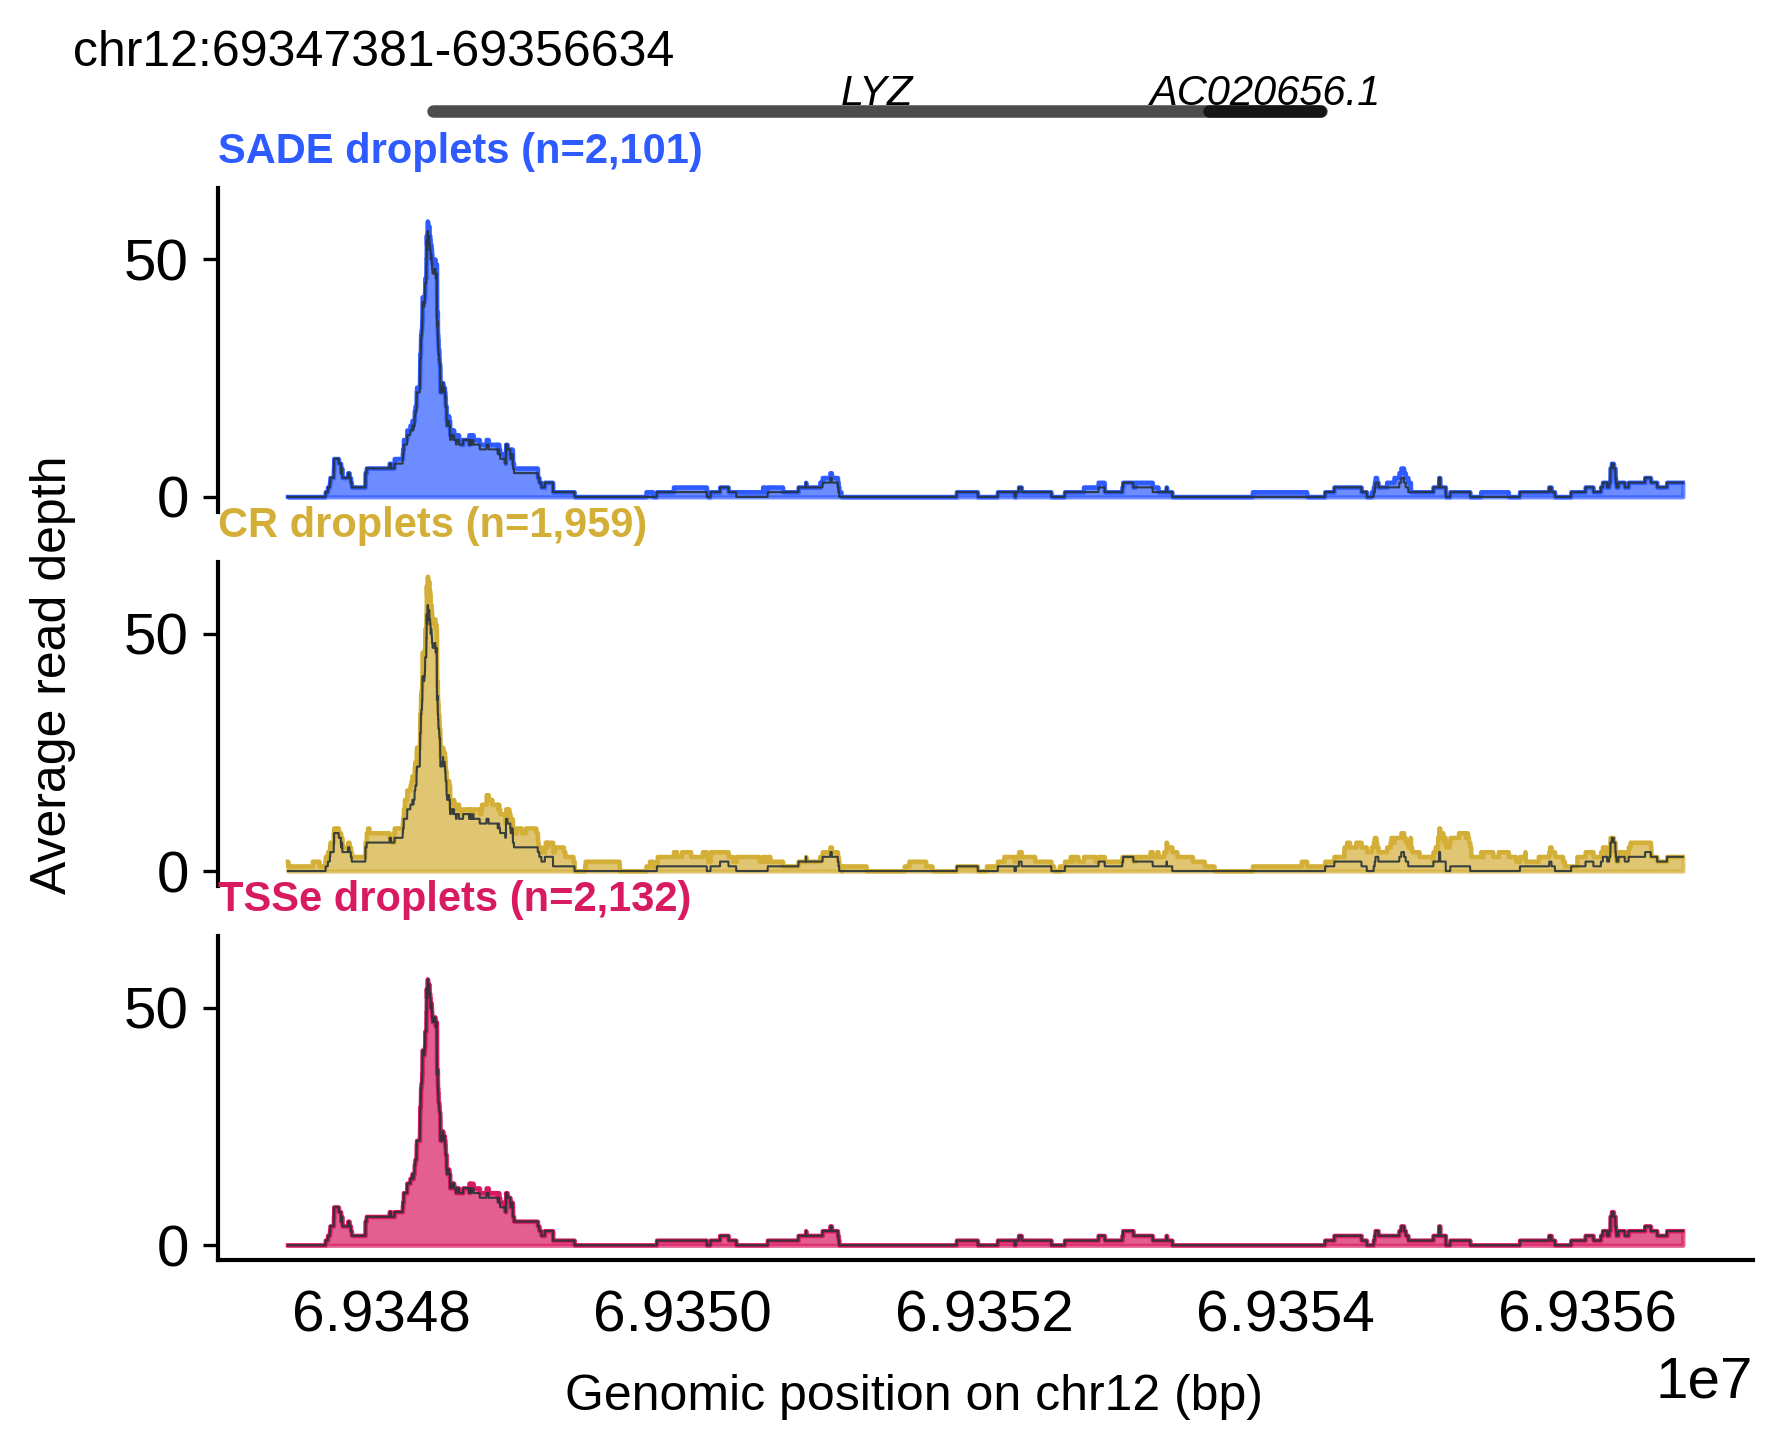

In [40]:
chrom = "chr12"
start = 69347381
end = 69356634

ratios = [0.1] + [1] * len(eachset_bw_files) 

fig, ax = plt.subplots( nrows=4,  ncols=1, figsize=(6.6, 5), sharex=True, sharey=True,
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37", '#D81B60']
labels = ['SADE droplets', 'CR droplets', 'TSSe droplets']
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS']):
    i = j + 1
    x_range = np.arange(start, end)
     
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
        
    # Process Common Reference BigWig
    c_bw = pyBigWig.open(set_bw_files['common'])
    common_values = np.nan_to_num(c_bw.values(chrom, start, end), nan=0.0)
    
    ax[i].fill_between(x_range, values, color=set_colors[j], alpha=0.7, label=labels[j])
    ax[i].plot(x_range, values, color=set_colors[j], lw=1)
    # Common
    # ax[i].fill_between(x_range, common_values, color='#263238', alpha=0.15, label='Common')
    ax[i].plot(x_range, common_values, color='#263238', lw=0.5, alpha=0.9)
    
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bw.close()
    c_bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [0.8 *ax[-1].get_ylim()[1]] * 2,  lw=3,color='black',solid_capstyle='round', alpha=0.7)
    ax[0].text((gene.start + gene.end)/2, ax[-1].get_ylim()[1] *2, gene.gene_name, 
                ha='center', va='top', fontsize=10, fontstyle='italic')

ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=0.93, fontsize=12,)
fig.text(0.03, 0.5, "Average read depth", fontsize=12, rotation=90, va='center')
fig.text(0.3, 0.01, f"Genomic position on {chrom} (bp)", fontsize=12)

#fig.tight_layout()

In [41]:
chrom = "chr1"
start = 47330790
end = 47381039


Text(0.5, 0.02, 'Chromosome Position')

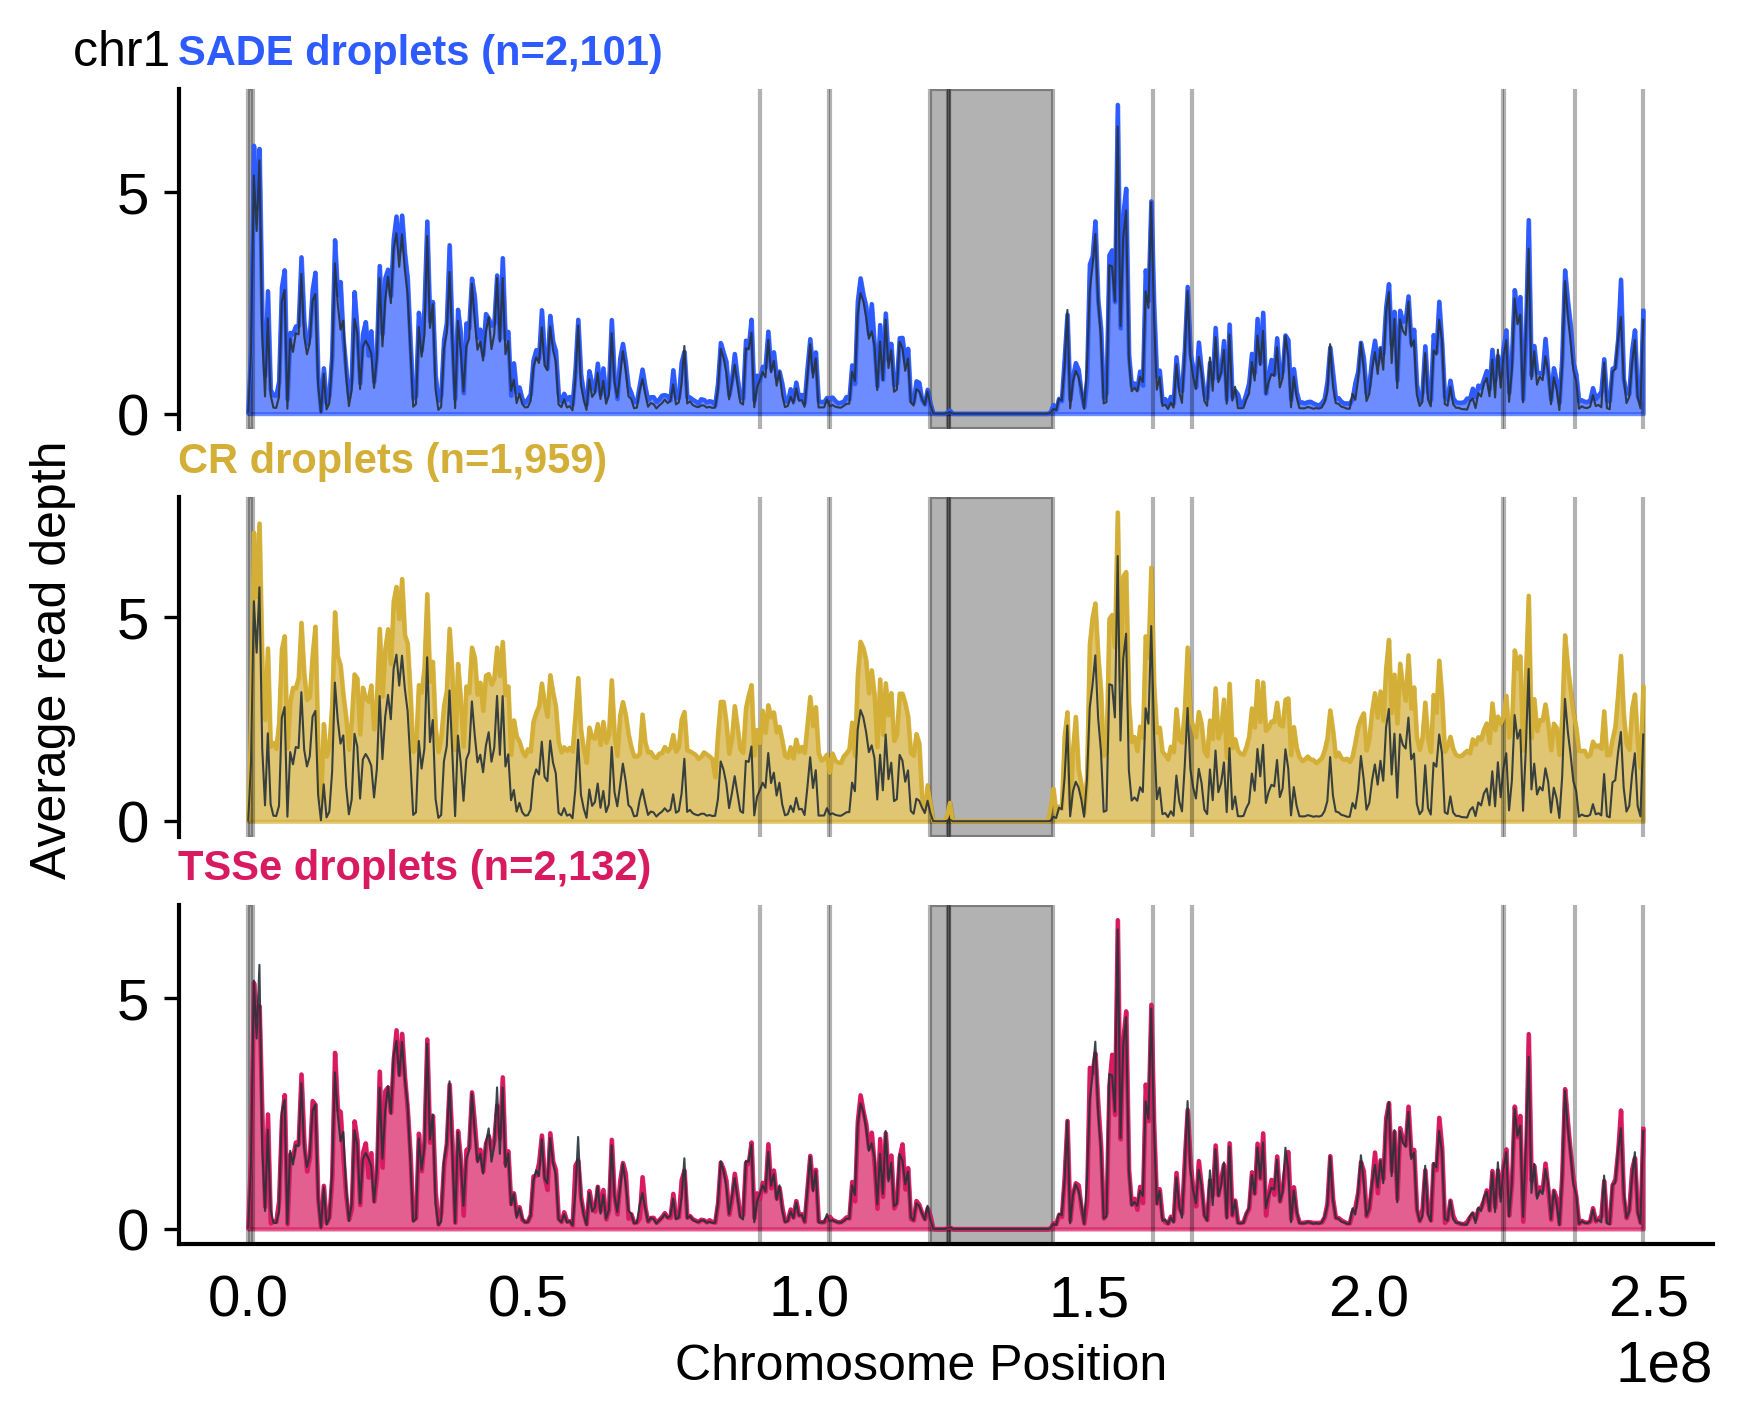

In [42]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=3, figsize=(6.6, 5), sharex=True)
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37", '#D81B60']
labels = ['SADE droplets', 'CR droplets', 'TSSe droplets']
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS']):
    i = j 
    
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    bw_chrom_size = bw.chroms(chrom)
    bw_binned_stats = bw.stats(chrom, 0, bw_chrom_size, nBins=bins, type="mean")

    ref_bw_file = set_bw_files['common']
    ref_bw = pyBigWig.open(ref_bw_file)
    ref_bw_chrom_size = ref_bw.chroms(chrom)
    ref_bw_binned_stats = ref_bw.stats(chrom, 0, ref_bw_chrom_size, nBins=bins, type="mean")
    
    x_range = np.linspace(0, bw_chrom_size, bins)
    
    ax[i].fill_between(x_range, bw_binned_stats, color=set_colors[j], alpha=0.7, label=labels[j])
    ax[i].plot(x_range, bw_binned_stats, color=set_colors[j], lw=1)
    # Common
    ax[i].plot(x_range, ref_bw_binned_stats, color='#263238', lw=0.5, alpha=0.9)
    
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bw.close()
    ref_bw.close()
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='black', alpha=0.3)

ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f'{chrom} ', y=0.92, x=0.1,fontsize=12)
fig.text(0.05, 0.5, 'Average read depth', fontsize=12, rotation=90, va='center')
fig.text(0.5, 0.02, f"Chromosome Position",fontsize=12,  rotation=0, ha='center')

# Focus on SADE vs CR

In [43]:
bc_SC_overlap_list =  union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC_mod'] == 'both'].index.tolist()
bc_SC_SADEunique_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC_mod'] == 'entropy_only'].index.tolist()
bc_SC_CRunique_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC_mod'] == 'cr_only'].index.tolist()


frag_overlap_SC = frag.loc[frag['atac_bc'].isin(bc_SC_overlap_list), 'frag_length']
frag_SADEunique_SC = frag.loc[frag['atac_bc'].isin(bc_SC_SADEunique_list), 'frag_length']
frag_CRunique_SC = frag.loc[frag['atac_bc'].isin(bc_SC_CRunique_list), 'frag_length']

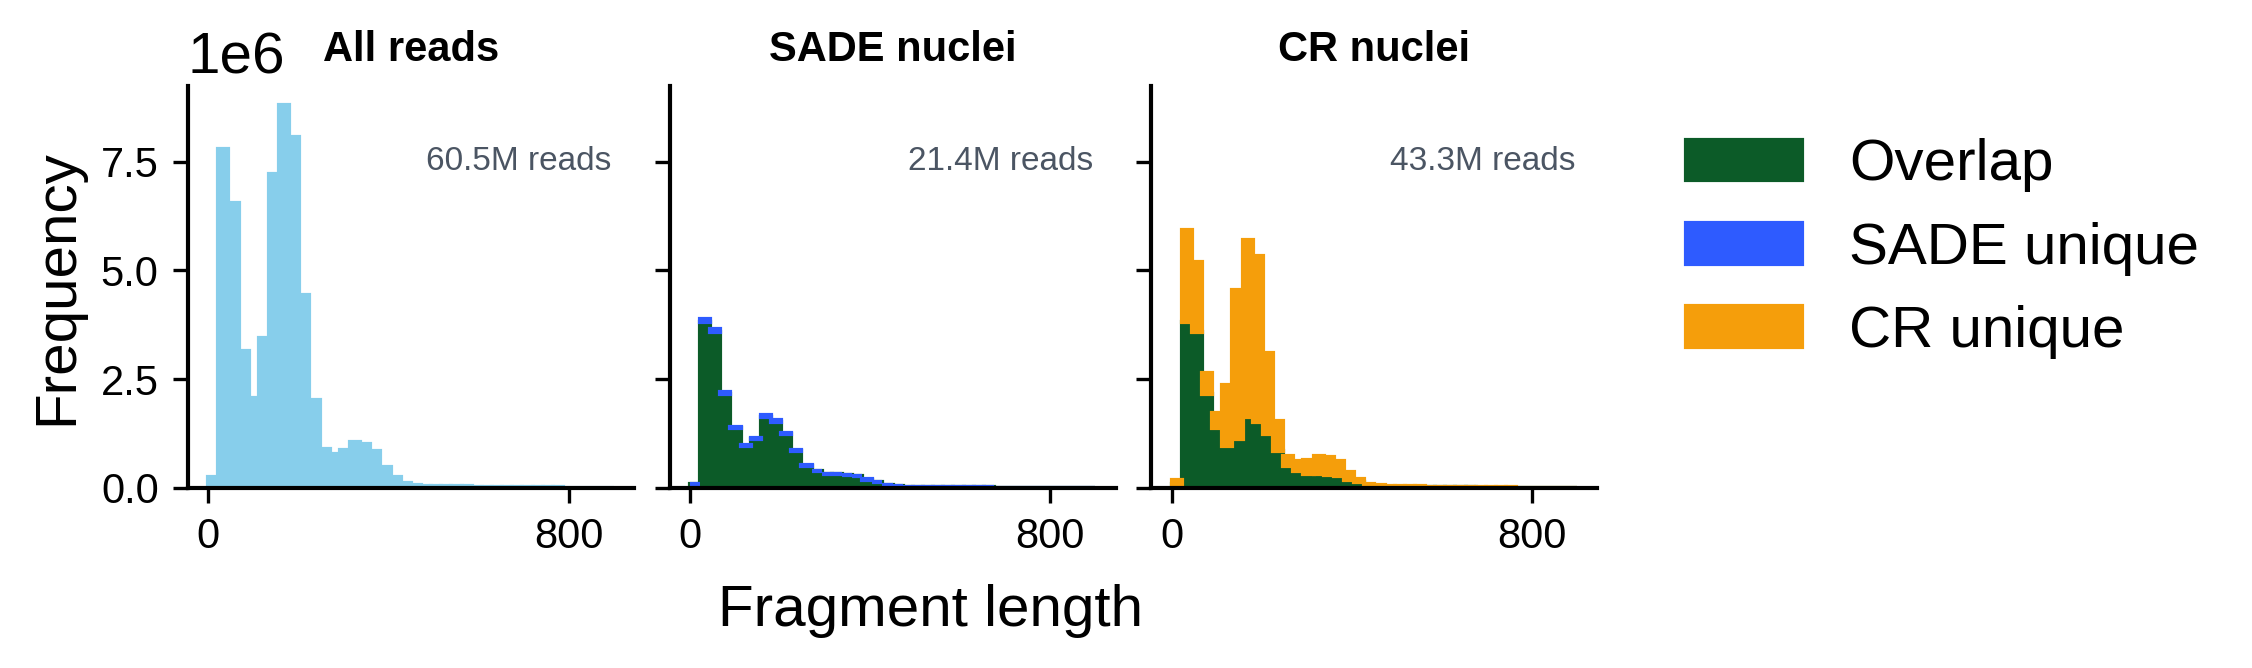

In [49]:

sade_nuclei_frag = [frag_overlap_SC, frag_SADEunique_SC]
cr_nuclei_frag = [frag_overlap_SC, frag_CRunique_SC]
all_reads = frag['frag_length']

sade_colors = [SADEvsCR_colors_map.get(s, 'grey') for s in ['both', 'entropy_only']]
cr_colors = [SADEvsCR_colors_map.get(s, 'grey') for s in ['both', 'cr_only']]
all_reads_colors = ['green']

fig = plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1,1.5], hspace=0.3)


gs1 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], width_ratios=[1, 1, 1, 0.2], wspace=0.1)
ax0 = fig.add_subplot(gs1[0])

ax = [ax0] + [fig.add_subplot(gs1[i], sharey=ax0) for i in range(1, 4)]



# All reads 
ax[0].hist(all_reads, bins=40, range=(0, 900), color='skyblue', alpha=1, edgecolor='skyblue')
ax[0].text(0.95, 0.85, f'{len(all_reads) / 1e6:.1f}M reads', transform=ax[0].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')
ax[0].set_title('All reads', fontweight='bold', fontsize=10)

for i in range(3):
    ax[i].set_xticks([0, 800])
    ax[i].tick_params(axis='x', which='major' ,labelsize=10)
    ax[i].tick_params(axis='y', which='major' ,labelsize=10)
    ax[i].spines[['top', 'right']].set_visible(False)

for s, c, t, i in zip([sade_nuclei_frag, cr_nuclei_frag], 
                   [sade_colors, cr_colors],
                   ['SADE', 'CR'], 
                   range(1, 3)):
    _ = ax[i].hist(s, bins=40, range=(0, 900), stacked=True, color=c, alpha=1, edgecolor=c)
    ax[i].set_title(f"{t} nuclei", fontweight='bold', fontsize=10)
    ax[i].text(0.95, 0.85, f'{np.sum([len(frag) for frag in s]) / 1e6:.1f}M reads', 
               transform=ax[i].transAxes, ha='right', va='top', fontsize=8, color='#4B5563')
    ax[i].tick_params(axis='y', which='major',  labelleft=False, labelsize=10)
    ax[i].tick_params(axis='x', which='major', labelsize=10)



ax[3].axis('off')
handles = [mpatches.Patch(color=SADEvsCR_colors_map[s], label=SADEvsCR_label_map[s]) for s in SADEvsCR_unique_categoris if s not in ('none', 'tss_only')] 
ax[3].legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(0, 1) )

ax[0].set_ylabel('Frequency')
fig.text(0.5, 0.52, 'Fragment length', ha='center')#, fontweight='bold')

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p3.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p3.pdf'), bbox_inches='tight')

In [50]:
SADEvsCR_colors_map

{'both': '#0C5B28',
 'entropy_only': '#2E5BFF',
 'cr_only': '#F59E0B',
 'none': '#94A3B8',
 'tss_only': '#D81B60'}

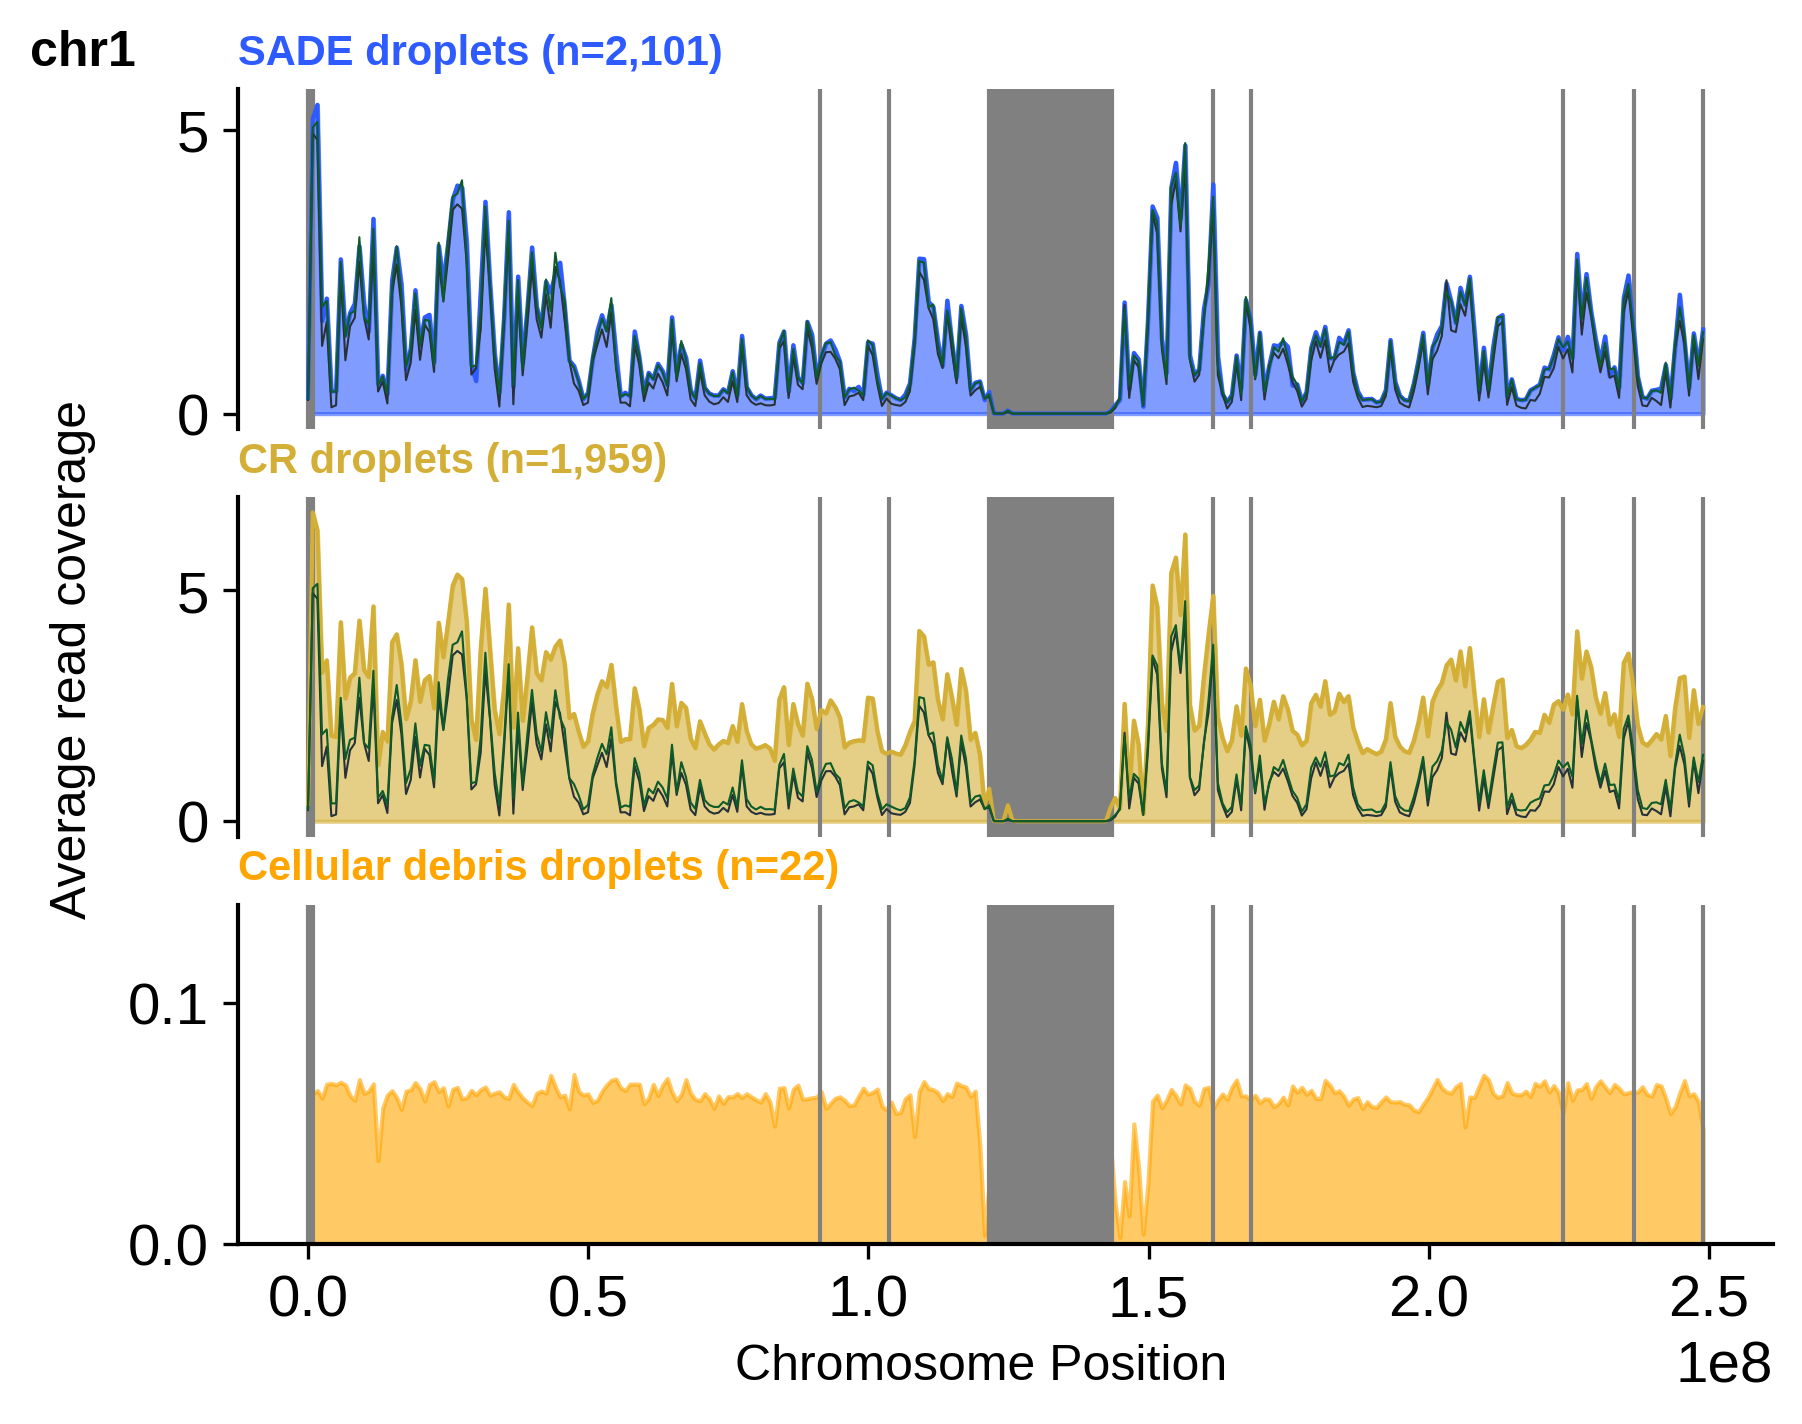

In [51]:
chrom = "chr1"
bins = 300

fig,ax = plt.subplots(ncols=1, nrows=3, figsize=(6.6, 5), sharex=True, )
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37",]
labels = ['SADE droplets', 'CR droplets', ]
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR']):
    i = j 
    
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    bw_chrom_size = bw.chroms(chrom)
    bw_binned_stats = bw.stats(chrom, 0, bw_chrom_size, nBins=bins, type="mean")

    ref_bw_file = set_bw_files['common']
    ref_bw = pyBigWig.open(ref_bw_file)
    ref_bw_chrom_size = ref_bw.chroms(chrom)
    ref_bw_binned_stats = ref_bw.stats(chrom, 0, ref_bw_chrom_size, nBins=bins, type="mean")
    
    ref_bw_overlap_file = subset_cmp_SC_bw_files['common']
    ref_overlap_bw = pyBigWig.open(ref_bw_overlap_file)
    ref_overlap_chrom_size = ref_overlap_bw.chroms(chrom)
    ref_overlap_binned_stats = ref_overlap_bw.stats(chrom, 0, ref_overlap_chrom_size, nBins=bins, type="mean")
    
    x_range = np.linspace(0, bw_chrom_size, bins)
    
    ax[i].fill_between(x_range, bw_binned_stats, color=set_colors[j], alpha=0.6, label=labels[j])
    ax[i].plot(x_range, bw_binned_stats, color=set_colors[j], lw=1)
    # Common among 3 filtering appraoches 
    ax[i].plot(x_range, ref_bw_binned_stats, color='#263238', lw=0.5, alpha=1)
    # overlap between SC (SADE and CR)
    ax[i].plot(x_range, ref_overlap_binned_stats, color='#0C5B28', lw=0.5, alpha=1, label='SC+SADE/CR common')
    
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bw.close()
    ref_bw.close()
    ref_overlap_bw.close()



debris_bw_file = debris_set_bw_files['DNAdebris']
debris_bw = pyBigWig.open(debris_bw_file)
debris_chrom_size = debris_bw.chroms(chrom)
debris_binned_stats = debris_bw.stats(chrom, 0, debris_chrom_size, nBins=bins, type="mean")
debris_binned_stats = np.nan_to_num(np.array(debris_binned_stats, dtype=float), nan=0.0)
ax[-1].fill_between(x_range, debris_binned_stats, color='orange', alpha=0.6, label=labels[j])
ax[-1].set_ylim(0, max(debris_binned_stats)*2)
ax[-1].set_title(f'Cellular debris droplets (n={(union_cell_info["DNA_debris"] == "YES").sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color='orange')
debris_bw.close()

for _ax in ax:
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        _ax.axvspan(row['start'], row['end'], color='grey', alpha=1)
        _ax.spines[['top', 'right']].set_visible(False)


ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f'{chrom} ', y=0.92, x=0.05,fontsize=12, fontweight='bold')
fig.text(0.03, 0.5, 'Average read coverage', fontsize=12, rotation=90, va='center')
fig.text(0.5, 0.02, f"Chromosome Position",fontsize=12,  rotation=0, ha='center')


fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p4.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p4.pdf'), bbox_inches='tight')

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

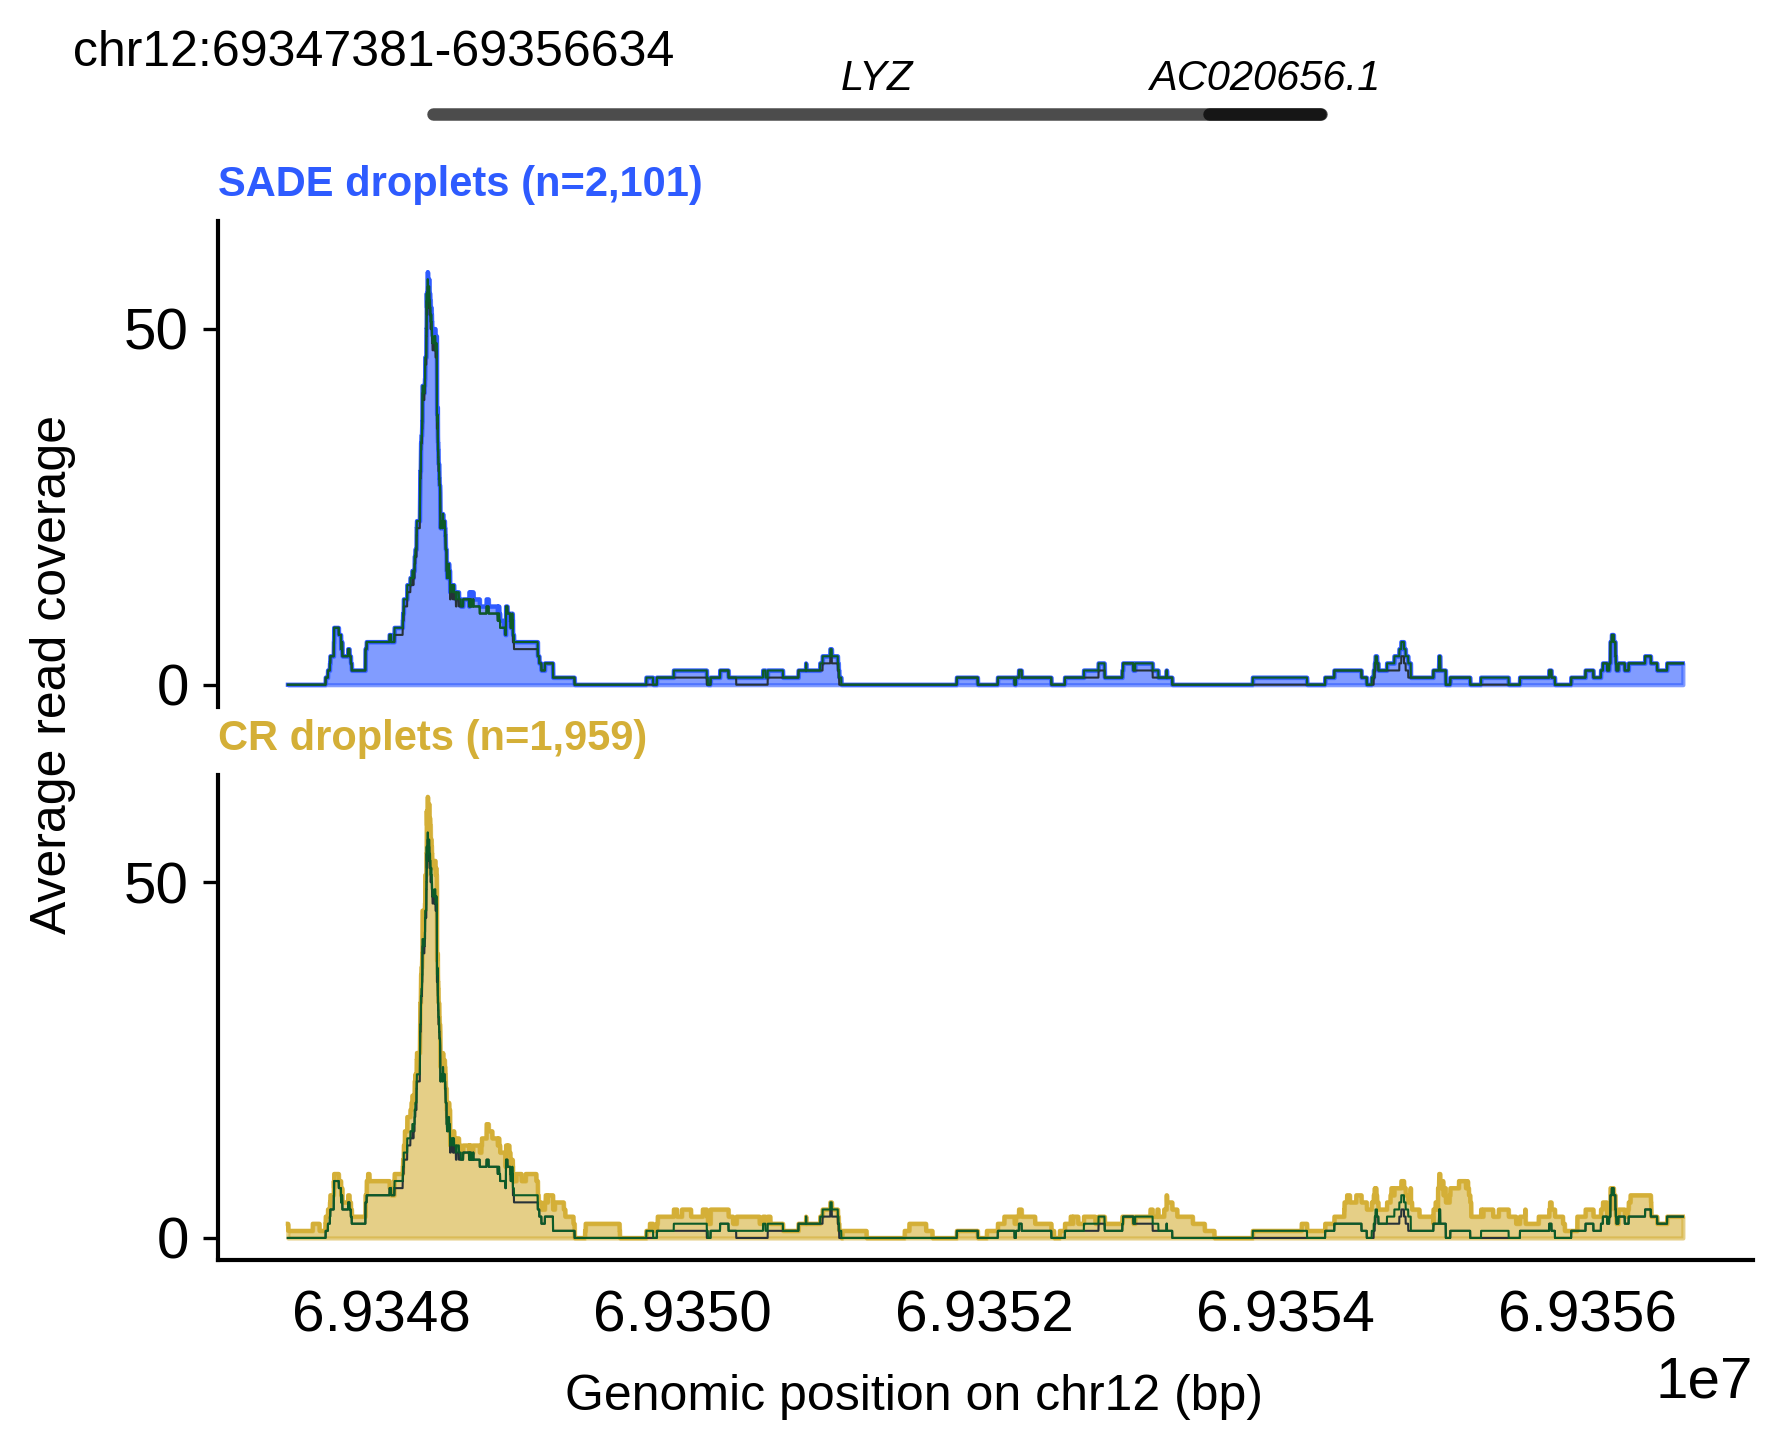

In [52]:
chrom = "chr12"
start = 69347381
end = 69356634

ratios = [0.1] + [1] * 2

fig, ax = plt.subplots( nrows=3,  ncols=1, figsize=(6.6, 5), sharex=True, sharey=True,
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37", ]
labels = ['SADE droplets', 'CR droplets']
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR',]):
    i = j + 1
    x_range = np.arange(start, end)
     
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
        
    # Process Common Reference BigWig
    c_bw = pyBigWig.open(set_bw_files['common'])
    common_values = np.nan_to_num(c_bw.values(chrom, start, end), nan=0.0)
    print(c_bw.values(chrom, start, end))


    ref_overlap_bw = pyBigWig.open(subset_cmp_SC_bw_files['common'])
    overlap_values = np.nan_to_num(ref_overlap_bw.values(chrom, start, end), nan=0.0)

    ax[i].fill_between(x_range, values, color=set_colors[j], alpha=0.6, label=labels[j])
    ax[i].plot(x_range, values, color=set_colors[j], lw=1)
    # Common among 3 filtering appraoches 
    ax[i].plot(x_range, common_values, color='#263238', lw=0.5, alpha=1)
    # overlap between SC (SADE and CR)
    ax[i].plot(x_range, overlap_values, color='#0C5B28', lw=0.5, alpha=1, )
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bw.close()
    c_bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [0.8 *ax[-1].get_ylim()[1]] * 2,  lw=3,color='black',solid_capstyle='round', alpha=0.7)
    ax[0].text((gene.start + gene.end)/2, ax[-1].get_ylim()[1] *2, gene.gene_name, 
                ha='center', va='top', fontsize=10, fontstyle='italic')

ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=0.93, fontsize=12,)
fig.text(0.03, 0.5, "Average read coverage", fontsize=12, rotation=90, va='center')
fig.text(0.3, 0.01, f"Genomic position on {chrom} (bp)", fontsize=12)

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p5.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig3_p5.pdf'), bbox_inches='tight')